# NovaCred Data Governance Task Force: Privacy & Compliance Analysis

## Executive Summary

We conduct a full privacy and compliance assessment of NovaCred's credit application dataset across 496 records. **We find that NovaCred has no functioning governance infrastructure: 5 direct PII fields are stored in plaintext, all 6 mandatory GDPR governance fields are completely absent across every record, and the credit scoring system qualifies as High-Risk AI under EU AI Act Annex III — satisfying 0 out of 6 mandatory requirements.**

### Key Findings Summary

| **Category** | **Finding** | **Severity** | **GDPR / AI Act Reference** |
|---|---|---|---|
| **Direct PII** | 5 direct identifier fields stored in plaintext; 3 not necessary for credit decision | 🔴 CRITICAL | Art. 4(1), Art. 25 |
| **Quasi-Identifiers** | ZIP + Gender + Age band: k-min = 1, 85.8% of groups uniquely identifiable | 🔴 CRITICAL | Art. 4(1), Recital 26 |
| **Consent Tracking** | consent_timestamp absent in all 496 records — lawful basis unprovable | 🔴 CRITICAL | Art. 6, Art. 7 |
| **Data Retention** | retention_until absent in all 496 records — data may be kept indefinitely | 🔴 CRITICAL | Art. 5(1)(e) |
| **Human Oversight** | human_review_flag absent — all 496 decisions fully automated, no override mechanism | 🔴 CRITICAL | Art. 22 |
| **GDPR Violations** | 9 violations mapped across 11 principles: 6 CRITICAL, 3 HIGH RISK | 🔴 CRITICAL | Art. 5, 6, 7, 17, 22, 25 |
| **Pseudonymisation** | SSN (492 records) and email (493 records) successfully pseudonymised via HMAC-SHA256 | ✅ Demonstrated | Art. 4(5), Art. 25 |
| **EU AI Act** | High-Risk AI (Annex III Cat. 5(b)): 4 NOT MET, 2 PARTIAL, 0 fully compliant | 🔴 CRITICAL | Art. 9, 10, 11, 13, 14, 15 |
| **Governance Roadmap** | 10 controls proposed: 4 immediate (0–30d), 4 short-term (30–90d), 2 medium-term (90–180d) | 📋 Actionable | Art. 5(2), Art. 35, AI Act Art. 9 |

## Table of Contents
1. [Library Overview](#library-overview)
2. [Data Loading and Preparation](#data-loading-and-preparation)
3. [PII Inventory: Direct Identifiers](#pii-inventory-direct-identifiers)
4. [PII Inventory: Quasi-Identifiers](#pii-inventory-quasi-identifiers)
5. [GDPR Compliance Gap Analysis](#gdpr-compliance-gap-analysis)
6. [EU AI Act Classification](#eu-ai-act-classification)

---

## Library Overview

**Libraries Used in This Analysis:**

| Library | Purpose |
|---------|---------|
| **pandas** | Data manipulation, analysis, and DataFrame operations |
| **numpy** | Numerical computations |
| **matplotlib** | Low-level visualization and plot creation |
| **seaborn** | Statistical data visualization with enhanced aesthetics |
| **json** | JSON file I/O for data loading |
| **datetime** | Timestamp generation for analysis logging |
| **warnings** | Control and filter warning messages |

In [5]:
# ============================================================================
# IMPORT STATEMENTS - All libraries required for privacy & compliance analysis
# ============================================================================

# Data manipulation
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Privacy / cryptography
import hashlib
import hmac
import secrets

# Utilities
import json
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"   Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
   Analysis Date: 2026-03-06 22:01:01


## Data Loading and Preparation

We load the cleaned dataset produced by Notebook 1 (`data_cleaned.json`). All data quality issues have already been resolved upstream — this notebook focuses exclusively on privacy, compliance, and governance dimensions.

In [6]:
# ============================================================================
# DATA LOADING
# Load the cleaned JSON produced by Notebook 1
# ============================================================================

with open('../data/data_cleaned.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

print(f"✅ Loaded {len(raw_data)} credit applications from data_cleaned.json")


# ============================================================================
# FLATTEN NESTED JSON
# Retains all PII fields in original form for the privacy audit
# ============================================================================

def flatten_application(app):
    """
    Flatten nested JSON structure into a single-level dictionary.
    Governance fields (consent, retention, etc.) are explicitly extracted
    so their absence is visible as NaN rather than a KeyError.
    """
    return {
        # --- Direct Identifiers (PII) ---
        'applicant_id':           app.get('original_id'),
        'full_name':              app.get('applicant_info', {}).get('full_name'),
        'email':                  app.get('applicant_info', {}).get('email'),
        'ssn':                    app.get('applicant_info', {}).get('ssn'),
        'ip_address':             app.get('applicant_info', {}).get('ip_address'),
        'date_of_birth':          app.get('applicant_info', {}).get('date_of_birth'),

        # --- Quasi-Identifiers ---
        'gender':                 app.get('applicant_info', {}).get('gender'),
        'zip_code':               app.get('applicant_info', {}).get('zip_code'),

        # --- Financial Information ---
        'annual_income':          app.get('financials', {}).get('annual_income'),
        'credit_history_months':  app.get('financials', {}).get('credit_history_months'),
        'debt_to_income':         app.get('financials', {}).get('debt_to_income'),
        'savings_balance':        app.get('financials', {}).get('savings_balance'),

        # --- Decision Information ---
        'loan_approved':          app.get('decision', {}).get('loan_approved'),
        'rejection_reason':       app.get('decision', {}).get('rejection_reason'),

        # --- Governance Fields (expected but likely missing) ---
        'consent_timestamp':      app.get('consent_timestamp'),
        'retention_until':        app.get('retention_until'),
        'processing_purpose':     app.get('processing_purpose'),
        'data_source':            app.get('data_source'),
        'human_review_flag':      app.get('human_review_flag'),
        'audit_trail':            app.get('audit_trail'),
    }


df = pd.DataFrame([flatten_application(app) for app in raw_data])

# Derive age for quasi-identifier analysis
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['age'] = (pd.Timestamp.now() - df['date_of_birth']).dt.days // 365

print(f"\n📊 DataFrame Shape: {df.shape[0]} records × {df.shape[1]} columns")
print(f"✅ Data successfully prepared for privacy analysis")
df.head(3)


✅ Loaded 496 credit applications from data_cleaned.json

📊 DataFrame Shape: 496 records × 21 columns
✅ Data successfully prepared for privacy analysis


,applicant_id,full_name,email,ssn,ip_address,date_of_birth,gender,zip_code,annual_income,credit_history_months,...,savings_balance,loan_approved,rejection_reason,consent_timestamp,retention_until,processing_purpose,data_source,human_review_flag,audit_trail,age
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,2001-03-09,Male,10036,73000,23.0,...,31212.0,False,algorithm_risk_score,None,None,None,None,None,None,25
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,1992-03-31,Male,10032,78000,51.0,...,17915.0,False,algorithm_risk_score,None,None,None,None,None,None,33
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,1989-10-24,Male,10075,61000,41.0,...,37909.0,True,None,None,None,None,None,None,None,36


---

## Analysis 1: PII Inventory — Direct Identifiers

**GDPR Reference:** Art. 4(1), Art. 25, Art. 5(1)(c)

Direct identifiers unambiguously identify a natural person on their own. Storing them in plaintext without protection violates GDPR Art. 25 (Data Protection by Design). We catalogue every such field in the NovaCred dataset, assess its sensitivity, completeness, and whether it is strictly necessary for the credit decision (data minimisation test under Art. 5(1)(c)).

In [7]:
# ============================================================================
# ANALYSIS 1: DIRECT IDENTIFIER INVENTORY
# Catalogue all direct PII fields, assess completeness and minimisation
# ============================================================================

direct_identifiers = {
    'full_name':     {'gdpr_category': 'Personal Data (Art. 4(1))',     'sensitivity': 'HIGH',     'necessary_for_decision': True},
    'email':         {'gdpr_category': 'Personal Data (Art. 4(1))',     'sensitivity': 'HIGH',     'necessary_for_decision': False},
    'ssn':           {'gdpr_category': 'National ID — Special Category','sensitivity': 'CRITICAL', 'necessary_for_decision': False},
    'ip_address':    {'gdpr_category': 'Personal Data (CJEU C-582/14)', 'sensitivity': 'MEDIUM',   'necessary_for_decision': False},
    'date_of_birth': {'gdpr_category': 'Personal Data (Art. 4(1))',     'sensitivity': 'HIGH',     'necessary_for_decision': True},
}

print('=' * 80)
print('DIRECT IDENTIFIER AUDIT')
print('=' * 80)

results_direct = []
total = len(df)

for field, meta in direct_identifiers.items():
    present     = df[field].notna().sum()
    missing     = total - present
    pct_present = present / total * 100
    flag = '🔴' if meta['sensitivity'] == 'CRITICAL' else ('🟠' if meta['sensitivity'] == 'HIGH' else '🟡')
    necessary_str = 'Yes' if meta['necessary_for_decision'] else 'No — candidate for removal (Art. 5(1)(c))'

    results_direct.append({
        'Field':                  field,
        'GDPR Category':          meta['gdpr_category'],
        'Sensitivity':            meta['sensitivity'],
        'Necessary for Decision': necessary_str,
        'Records Present':        present,
        'Records Missing':        missing,
        '% Present':              f'{pct_present:.1f}%',
    })

    print(f'\n{flag} {field.upper()}')
    print(f"   GDPR Category  : {meta['gdpr_category']}")
    print(f"   Sensitivity    : {meta['sensitivity']}")
    print(f"   Necessary      : {necessary_str}")
    print(f"   Present        : {present:,} / {total:,} ({pct_present:.1f}%)")
    print(f"   Missing        : {missing:,}")

not_needed = sum(1 for m in direct_identifiers.values() if not m['necessary_for_decision'])
print('\n' + '=' * 80)
print(f'   Total direct identifier fields found      : {len(direct_identifiers)}')
print(f'   Fields NOT necessary for credit decision  : {not_needed} — violate Art. 5(1)(c)')
print('=' * 80)

df_results_direct = pd.DataFrame(results_direct)
df_results_direct

DIRECT IDENTIFIER AUDIT

🟠 FULL_NAME
   GDPR Category  : Personal Data (Art. 4(1))
   Sensitivity    : HIGH
   Necessary      : Yes
   Present        : 496 / 496 (100.0%)
   Missing        : 0

🟠 EMAIL
   GDPR Category  : Personal Data (Art. 4(1))
   Sensitivity    : HIGH
   Necessary      : No — candidate for removal (Art. 5(1)(c))
   Present        : 496 / 496 (100.0%)
   Missing        : 0

🔴 SSN
   GDPR Category  : National ID — Special Category
   Sensitivity    : CRITICAL
   Necessary      : No — candidate for removal (Art. 5(1)(c))
   Present        : 495 / 496 (99.8%)
   Missing        : 1

🟡 IP_ADDRESS
   GDPR Category  : Personal Data (CJEU C-582/14)
   Sensitivity    : MEDIUM
   Necessary      : No — candidate for removal (Art. 5(1)(c))
   Present        : 495 / 496 (99.8%)
   Missing        : 1

🟠 DATE_OF_BIRTH
   GDPR Category  : Personal Data (Art. 4(1))
   Sensitivity    : HIGH
   Necessary      : Yes
   Present        : 496 / 496 (100.0%)
   Missing        : 0

   Total

,Field,GDPR Category,Sensitivity,Necessary for Decision,Records Present,Records Missing,% Present
0,full_name,Personal Data (Art. 4(1)),HIGH,Yes,496,0,100.0%
1,email,Personal Data (Art. 4(1)),HIGH,No — candidate for removal (Art. 5(1)(c)),496,0,100.0%
2,ssn,National ID — Special Category,CRITICAL,No — candidate for removal (Art. 5(1)(c)),495,1,99.8%
3,ip_address,Personal Data (CJEU C-582/14),MEDIUM,No — candidate for removal (Art. 5(1)(c)),495,1,99.8%
4,date_of_birth,Personal Data (Art. 4(1)),HIGH,Yes,496,0,100.0%


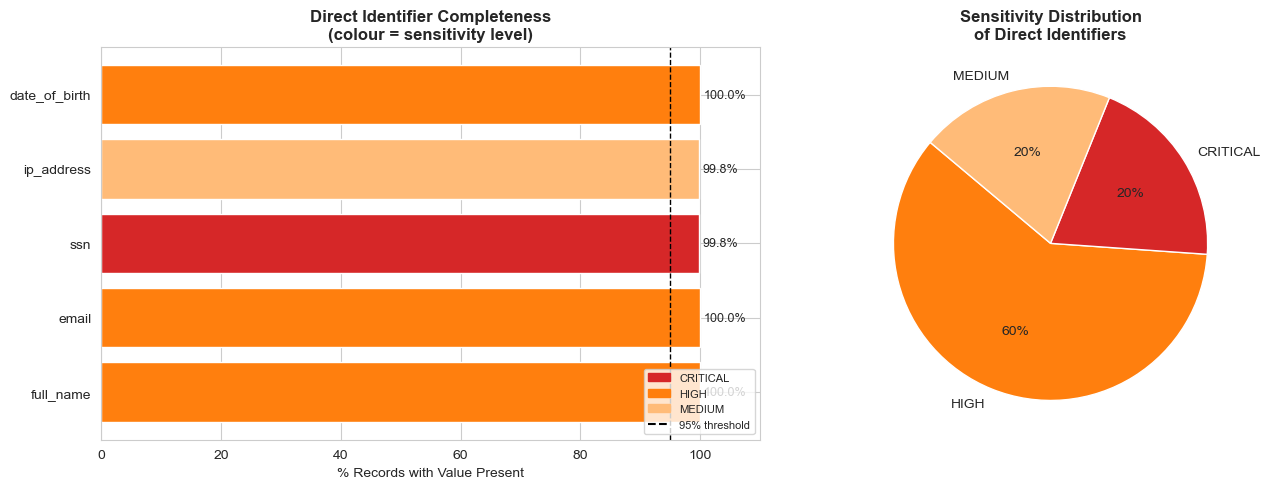

In [8]:
# ============================================================================
# VISUALISATION: Direct Identifier Completeness & Sensitivity
# ============================================================================

sensitivity_color = {'CRITICAL': '#d62728', 'HIGH': '#ff7f0e', 'MEDIUM': '#ffbb78'}
colors = [sensitivity_color[meta['sensitivity']] for meta in direct_identifiers.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Completeness bar chart ---
pct_values = [float(r['% Present'].replace('%', '')) for r in results_direct]
bars = axes[0].barh(df_results_direct['Field'], pct_values, color=colors, edgecolor='white')
axes[0].axvline(x=95, color='black', linestyle='--', linewidth=1, label='95% threshold')
axes[0].set_xlabel('% Records with Value Present')
axes[0].set_title('Direct Identifier Completeness\n(colour = sensitivity level)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 110)
for bar, val in zip(bars, pct_values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#d62728', label='CRITICAL'),
    mpatches.Patch(color='#ff7f0e', label='HIGH'),
    mpatches.Patch(color='#ffbb78', label='MEDIUM'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='95% threshold'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=8)

# --- Right: Sensitivity distribution pie ---
sensitivity_counts = pd.Series(
    [meta['sensitivity'] for meta in direct_identifiers.values()]
).value_counts()
pie_colors = [sensitivity_color.get(s, 'grey') for s in sensitivity_counts.index]
axes[1].pie(
    sensitivity_counts.values,
    labels=sensitivity_counts.index,
    colors=pie_colors,
    autopct='%1.0f%%',
    startangle=140
)
axes[1].set_title('Sensitivity Distribution\nof Direct Identifiers', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Analysis 1: Results and Findings

**Findings:** The NovaCred dataset contains **5 direct identifier fields**, all stored in plaintext without any cryptographic protection. Of these, **3 fields are not necessary for the credit decision** (email, SSN, IP address) and violate GDPR Art. 5(1)(c) — Data Minimisation.

- 🔴 **SSN** (CRITICAL): Present in 495/496 records (99.8%). A national identifier of the highest sensitivity — its storage in plaintext without encryption constitutes the most severe compliance gap in the dataset. Not required for algorithmic credit scoring.
- 🟠 **Email** (HIGH): Present in 496/496 records (100.0%). Not necessary for the credit decision — candidate for immediate pseudonymisation or removal.
- 🟠 **Full Name** (HIGH): Present in 496/496 records (100.0%). Necessary for identity verification, but must be pseudonymised in all analytical and model training contexts.
- 🟠 **Date of Birth** (HIGH): Present in 496/496 records (100.0%). Necessary for age derivation — retained but should not appear in downstream model features directly.
- 🟡 **IP Address** (MEDIUM): Present in 495/496 records (99.8%). No legitimate use case for credit decision-making — recommended for deletion under Art. 5(1)(c).

**Next step:** Pseudonymisation of SSN and email is demonstrated in Analysis 5. Quasi-identifier re-identification risk (ZIP + Gender + Age) is assessed in Analysis 2.

---

## Analysis 2: PII Inventory — Quasi-Identifiers & Re-identification Risk

**GDPR Reference:** Art. 4(1), Recital 26

Quasi-identifiers don't identify a person alone, but combinations can uniquely single out individuals, which Recital 26 treats as personal data processing. Sweeney (2000) showed that 87% of Americans are uniquely identifiable from ZIP + gender + date of birth alone. We test whether comparable re-identification risk exists in NovaCred by measuring k-anonymity across key quasi-identifier combinations, with k=5 as the minimum acceptable threshold.

In [9]:
# ============================================================================
# ANALYSIS 2: QUASI-IDENTIFIER & K-ANONYMITY ANALYSIS
# Measure re-identification risk for quasi-identifier combinations
# ============================================================================

# Bin age into 5-year bands (standard quasi-identifier generalisation)
df['age_band'] = (df['age'] // 5 * 5).astype('Int64').astype(str) + '-' + ((df['age'] // 5 * 5) + 4).astype('Int64').astype(str)

quasi_combinations = {
    'ZIP only':                  ['zip_code'],
    'Gender + Age band':         ['gender', 'age_band'],
    'ZIP + Gender':              ['zip_code', 'gender'],
    'ZIP + Age band':            ['zip_code', 'age_band'],
    'ZIP + Gender + Age band':   ['zip_code', 'gender', 'age_band'],
}

print('=' * 80)
print('QUASI-IDENTIFIER RE-IDENTIFICATION RISK (K-ANONYMITY ANALYSIS)')
print('=' * 80)

results_quasi = []

for combo_name, fields in quasi_combinations.items():
    valid = df[fields].dropna()
    group_sizes = valid.groupby(fields).size()
    k_min       = int(group_sizes.min())
    k_median    = float(group_sizes.median())
    pct_unique  = (group_sizes == 1).sum() / len(group_sizes) * 100
    status      = '🔴 HIGH RISK' if k_min < 5 else ('🟠 MODERATE' if k_min < 10 else '✅ LOW RISK')

    results_quasi.append({
        'Combination':          combo_name,
        'k-min':                k_min,
        'k-median':             round(k_median, 1),
        '% Unique Groups':      f'{pct_unique:.1f}%',
        'Re-id Risk':           status,
    })

    print(f'\n{status}  {combo_name}')
    print(f'   k-min (smallest group) : {k_min}  {"⚠️  Below k=5 threshold" if k_min < 5 else ""}')
    print(f'   k-median               : {k_median:.1f}')
    print(f'   % groups with k=1      : {pct_unique:.1f}%')

print('\n' + '=' * 80)

df_results_quasi = pd.DataFrame(results_quasi)
df_results_quasi

QUASI-IDENTIFIER RE-IDENTIFICATION RISK (K-ANONYMITY ANALYSIS)

🔴 HIGH RISK  ZIP only
   k-min (smallest group) : 1  ⚠️  Below k=5 threshold
   k-median               : 2.0
   % groups with k=1      : 25.8%

🟠 MODERATE  Gender + Age band
   k-min (smallest group) : 5  
   k-median               : 24.0
   % groups with k=1      : 0.0%

🔴 HIGH RISK  ZIP + Gender
   k-min (smallest group) : 1  ⚠️  Below k=5 threshold
   k-median               : 2.0
   % groups with k=1      : 42.9%

🔴 HIGH RISK  ZIP + Age band
   k-min (smallest group) : 1  ⚠️  Below k=5 threshold
   k-median               : 1.0
   % groups with k=1      : 83.1%

🔴 HIGH RISK  ZIP + Gender + Age band
   k-min (smallest group) : 1  ⚠️  Below k=5 threshold
   k-median               : 1.0
   % groups with k=1      : 85.8%



,Combination,k-min,k-median,% Unique Groups,Re-id Risk
0,ZIP only,1,2.0,25.8%,🔴 HIGH RISK
1,Gender + Age band,5,24.0,0.0%,🟠 MODERATE
2,ZIP + Gender,1,2.0,42.9%,🔴 HIGH RISK
3,ZIP + Age band,1,1.0,83.1%,🔴 HIGH RISK
4,ZIP + Gender + Age band,1,1.0,85.8%,🔴 HIGH RISK


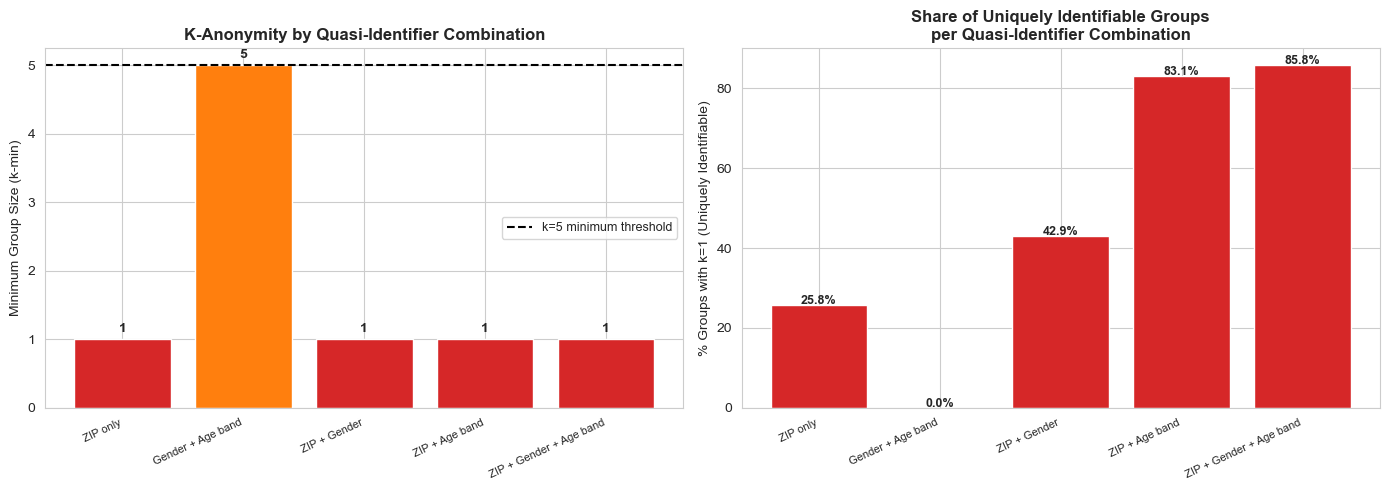

In [10]:
# ============================================================================
# VISUALISATION: K-Anonymity Distribution & Combination Risk
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: k-min bar chart per combination ---
risk_colors = ['#d62728' if r['k-min'] < 5 else ('#ff7f0e' if r['k-min'] < 10 else '#2ca02c')
               for r in results_quasi]
bars = axes[0].bar(
    [r['Combination'] for r in results_quasi],
    [r['k-min'] for r in results_quasi],
    color=risk_colors, edgecolor='white'
)
axes[0].axhline(y=5, color='black', linestyle='--', linewidth=1.5, label='k=5 minimum threshold')
axes[0].set_ylabel('Minimum Group Size (k-min)')
axes[0].set_title('K-Anonymity by Quasi-Identifier Combination', fontsize=12, fontweight='bold')
axes[0].set_xticklabels([r['Combination'] for r in results_quasi], rotation=25, ha='right', fontsize=8)
for bar, val in zip(bars, [r['k-min'] for r in results_quasi]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.1, str(val),
                 ha='center', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)

# --- Right: % unique groups (k=1) per combination ---
pct_unique_vals = [float(r['% Unique Groups'].replace('%', '')) for r in results_quasi]
axes[1].bar(
    [r['Combination'] for r in results_quasi],
    pct_unique_vals,
    color=risk_colors, edgecolor='white'
)
axes[1].set_ylabel('% Groups with k=1 (Uniquely Identifiable)')
axes[1].set_title('Share of Uniquely Identifiable Groups\nper Quasi-Identifier Combination', fontsize=12, fontweight='bold')
axes[1].set_xticklabels([r['Combination'] for r in results_quasi], rotation=25, ha='right', fontsize=8)
for i, val in enumerate(pct_unique_vals):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Analysis 2b: k-Anonymity Weaknesses — Homogeneity Attack & l-Diversity

**Lecture Reference:** k-Anonymity has known weaknesses even when k ≥ 5 is satisfied. Two key attack vectors from the lecture:
1. **Homogeneity Attack:** If all records in a k-anonymity group share the same sensitive value, knowing someone is in that group reveals their sensitive attribute, regardless of k.
2. **Background Knowledge Attack:** External information can narrow down possibilities within a group (e.g., knowing someone runs marathons makes "Heart Disease" unlikely).

**Countermeasures:** l-Diversity (each group must contain ≥ l distinct sensitive values) and t-Closeness (distribution of sensitive values per group must be close to the overall distribution).

We test whether the NovaCred dataset is vulnerable to homogeneity attacks on the `loan_approved` decision, and compute l-Diversity for each quasi-identifier group.

In [ ]:
# ============================================================================
# ANALYSIS 2b: K-ANONYMITY WEAKNESSES
# Homogeneity attack detection + l-Diversity measurement
# ============================================================================

# Use the most dangerous combination from Analysis 2: ZIP + Gender + Age band
qi_fields = ['zip_code', 'gender', 'age_band']
sensitive_field = 'loan_approved'

# Drop rows with missing quasi-identifiers or sensitive value
df_qi = df[qi_fields + [sensitive_field]].dropna().copy()

print('=' * 80)
print('K-ANONYMITY WEAKNESS ANALYSIS')
print(f'Quasi-identifiers : {qi_fields}')
print(f'Sensitive field    : {sensitive_field}')
print('=' * 80)

# ── 1. HOMOGENEITY ATTACK DETECTION ─────────────────────────────────────────
# A group is vulnerable if ALL members share the same loan_approved value → an attacker who knows someone is in that group knows their decision

groups = df_qi.groupby(qi_fields)

homogeneity_results = []
for name, group in groups:
    unique_sensitive = group[sensitive_field].nunique()
    homogeneity_results.append({
        'group': name,
        'k': len(group),
        'l_diversity': unique_sensitive,
        'homogeneous': unique_sensitive == 1,
        'decision_value': group[sensitive_field].iloc[0] if unique_sensitive == 1 else 'mixed',
    })

df_homogeneity = pd.DataFrame(homogeneity_results)

n_groups = len(df_homogeneity)
n_homogeneous = df_homogeneity['homogeneous'].sum()
pct_homogeneous = n_homogeneous / n_groups * 100
n_records_exposed = df_homogeneity[df_homogeneity['homogeneous']]['k'].sum()

print(f'\n── HOMOGENEITY ATTACK ──')
print(f'   Total quasi-identifier groups    : {n_groups}')
print(f'   Homogeneous groups (l = 1)       : {n_homogeneous} ({pct_homogeneous:.1f}%)')
print(f'   Records in homogeneous groups    : {n_records_exposed}')
print(f'   → These individuals\' {sensitive_field} decision is fully exposed')

# Show examples of homogeneous groups
print(f'\n   Example homogeneous groups (attacker knows the decision):')
examples = df_homogeneity[df_homogeneity['homogeneous']].head(5)
for _, row in examples.iterrows():
    zip_c, gen, age = row['group']
    print(f'     ZIP={zip_c}, Gender={gen}, Age={age}  →  k={row["k"]}, '
          f'ALL {sensitive_field}={row["decision_value"]}')

# ── 2. L-DIVERSITY MEASUREMENT ───────────────────────────────────────────────
# l-Diversity: each group must have ≥ l distinct values of the sensitive field
# For binary loan_approved, max possible l = 2

print(f'\n── L-DIVERSITY ANALYSIS ──')
l_counts = df_homogeneity['l_diversity'].value_counts().sort_index()
for l_val, count in l_counts.items():
    pct = count / n_groups * 100
    status = '🔴 VULNERABLE' if l_val == 1 else '✅ Diverse'
    print(f'   l = {l_val} : {count} groups ({pct:.1f}%) — {status}')

# What l-diversity threshold is achievable?
min_l = df_homogeneity['l_diversity'].min()
print(f'\n   Minimum l-diversity across all groups : {min_l}')
print(f'   → Dataset achieves {min_l}-diversity (target: l ≥ 2 for binary sensitive field)')
if min_l < 2:
    print(f'   ⚠️  {n_homogeneous} groups violate 2-diversity → homogeneity attack possible')

# ── 3. BACKGROUND KNOWLEDGE ATTACK SCENARIO ─────────────────────────────────
print(f'\n── BACKGROUND KNOWLEDGE ATTACK (Illustrative Scenario) ──')
print(f'   Scenario: An attacker knows that their neighbour:')
print(f'     - Lives in a specific ZIP code')
print(f'     - Is female, in her 30s')
print(f'   The attacker looks up the corresponding group in the dataset.')

# Find a concrete example group
example_group = df_homogeneity[
    (df_homogeneity['homogeneous']) & (df_homogeneity['k'] >= 1)
].iloc[0] if n_homogeneous > 0 else None

if example_group is not None:
    zip_c, gen, age = example_group['group']
    print(f'\n   Matching group: ZIP={zip_c}, Gender={gen}, Age={age}')
    print(f'   Group size (k) = {example_group["k"]} — k-anonymity is technically satisfied if k ≥ 1')
    print(f'   But l-diversity = 1 → ALL members have loan_approved = {example_group["decision_value"]}')
    print(f'   → The neighbour\'s credit decision is revealed despite k-anonymity!')
    print(f'\n   This is exactly the failure mode described in the lecture:')
    print(f'   k-anonymity protects identity, but NOT the sensitive attribute when groups are homogeneous.')

print('\n' + '=' * 80)
print('CONCLUSION: k-anonymity alone is insufficient for NovaCred.')
print('Recommended countermeasures from lecture:')
print('  1. l-Diversity: ensure each group has ≥ 2 distinct loan decisions')
print('  2. t-Closeness: ensure per-group decision distribution ≈ overall distribution')
print('  3. Differential Privacy: add calibrated noise to query outputs (Analysis 8)')
print('=' * 80)

K-ANONYMITY WEAKNESS ANALYSIS
Quasi-identifiers : ['zip_code', 'gender', 'age_band']
Sensitive field    : loan_approved

── HOMOGENEITY ATTACK ──
   Total quasi-identifier groups    : 430
   Homogeneous groups (l = 1)       : 406 (94.4%)
   Records in homogeneous groups    : 445
   → These individuals' loan_approved decision is fully exposed

   Example homogeneous groups (attacker knows the decision):
     ZIP=10001, Gender=Male, Age=20-24  →  k=1, ALL loan_approved=True
     ZIP=10001, Gender=Male, Age=35-39  →  k=1, ALL loan_approved=True
     ZIP=10001, Gender=Male, Age=55-59  →  k=1, ALL loan_approved=True
     ZIP=10001, Gender=Male, Age=60-64  →  k=1, ALL loan_approved=True
     ZIP=10002, Gender=Male, Age=30-34  →  k=1, ALL loan_approved=False

── L-DIVERSITY ANALYSIS ──
   l = 1 : 406 groups (94.4%) — 🔴 VULNERABLE
   l = 2 : 24 groups (5.6%) — ✅ Diverse

   Minimum l-diversity across all groups : 1
   → Dataset achieves 1-diversity (target: l ≥ 2 for binary sensitive field)
  

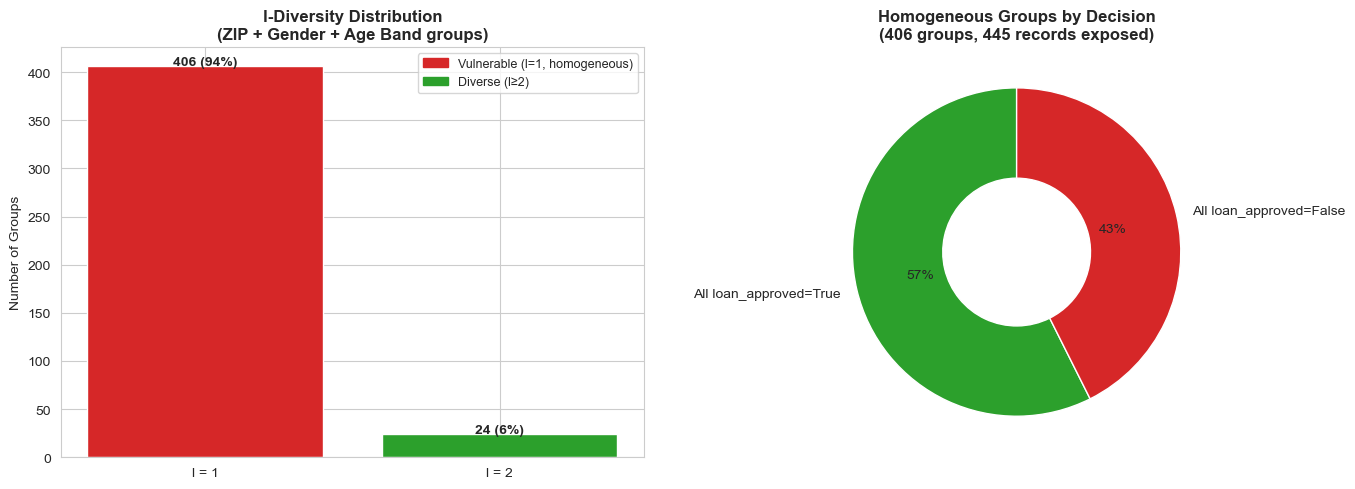

In [39]:
# ============================================================================
# VISUALISATION: Homogeneity Attack & l-Diversity
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: l-Diversity distribution ---
l_labels = [f'l = {l}' for l in l_counts.index]
l_colors = ['#d62728' if l == 1 else '#2ca02c' for l in l_counts.index]
bars = axes[0].bar(l_labels, l_counts.values, color=l_colors, edgecolor='white')
axes[0].set_ylabel('Number of Groups')
axes[0].set_title('l-Diversity Distribution\n(ZIP + Gender + Age Band groups)',
                   fontsize=12, fontweight='bold')
for bar, val in zip(bars, l_counts.values):
    pct = val / n_groups * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1,
                 f'{val} ({pct:.0f}%)', ha='center', fontsize=10, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#d62728', label='Vulnerable (l=1, homogeneous)'),
    mpatches.Patch(color='#2ca02c', label='Diverse (l≥2)'),
]
axes[0].legend(handles=legend_patches, fontsize=9)

# --- Right: Homogeneous groups by decision value ---
if n_homogeneous > 0:
    homo_decisions = df_homogeneity[df_homogeneity['homogeneous']]['decision_value'].value_counts()
    dec_labels = [f'All {sensitive_field}={v}' for v in homo_decisions.index]
    dec_colors = ['#2ca02c' if v == True else '#d62728' for v in homo_decisions.index]
    axes[1].pie(homo_decisions.values, labels=dec_labels, colors=dec_colors,
                autopct='%1.0f%%', startangle=90, wedgeprops=dict(width=0.55))
    axes[1].set_title(f'Homogeneous Groups by Decision\n({n_homogeneous} groups, {n_records_exposed} records exposed)',
                       fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No homogeneous groups found', ha='center', va='center')
    axes[1].set_title('Homogeneous Groups', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Analysis 2: Results and Findings

**Findings:** 4 out of 5 quasi-identifier combinations fail the k=5 minimum threshold, with k-min = 1 across all ZIP-based combinations. This means individuals can be **uniquely singled out** using only non-identifying fields — even without access to any direct identifier like SSN or name.

- 🔴 **ZIP + Gender + Age band** (most dangerous): k-min = 1, k-median = 1.0 — **85.8% of groups contain only a single individual**, making them uniquely identifiable. This directly violates GDPR Recital 26.
- 🔴 **ZIP + Age band**: k-min = 1, k-median = 1.0 — 83.1% uniquely identifiable groups. Adding age banding to ZIP alone nearly doubles the re-identification risk compared to ZIP only.
- 🔴 **ZIP + Gender**: k-min = 1, k-median = 2.0 — 42.9% uniquely identifiable groups. ZIP code alone drives most of this risk.
- 🔴 **ZIP only**: k-min = 1, k-median = 2.0 — already 25.8% of ZIP codes appear only once in the dataset, constituting a HIGH RISK even as a single field.
- 🟠 **Gender + Age band**: the only MODERATE combination (k-min = 5, 0.0% unique groups) — without ZIP code, gender and age alone do not create re-identification risk at this dataset size.

**k-Anonymity Weakness Analysis (Lecture Reference — "k-Anonymity: When It Fails"):**

Analysis 2b reveals that even achieving higher k-values would not protect the NovaCred dataset, because k-anonymity has two fundamental weaknesses identified in the lecture:

1. **Homogeneity Attack:** Of the 430 quasi-identifier groups (ZIP + Gender + Age band), **406 groups (94.4%) are homogeneous** — all members share the same `loan_approved` decision. This means 445 records are fully exposed: an attacker who knows someone belongs to such a group learns their credit decision with certainty, regardless of k. This mirrors the lecture example where all records in ZIP=301** share "Heart Disease". Among the homogeneous groups, 57% contain only approved applicants and 43% contain only rejected applicants, meaning the privacy breach disproportionately exposes rejection decisions, which are more sensitive and stigmatising.

2. **Background Knowledge Attack:** An attacker who knows basic facts about their neighbour (ZIP code, gender, approximate age —> all trivially available) can locate the corresponding group in the dataset. Because l-diversity = 1 in most groups, the sensitive attribute is immediately revealed. Unlike the lecture's Maria example, where specialised knowledge (marathon running) was needed to narrow down the options, NovaCred's extreme homogeneity means **no specialised background knowledge is required** — everyday demographic information suffices.

3. **l-Diversity:** The dataset achieves only **1-diversity** in the worst case. For a binary sensitive field like `loan_approved`, the minimum acceptable threshold is l ≥ 2 (both outcomes must appear in every group). Only 24 groups (5.6%) meet this standard. This confirms that the l-Diversity countermeasure proposed in the lecture is not satisfied, and that k-anonymity alone, even if strengthened, cannot protect NovaCred's data.

**Key implication:** ZIP code is the primary driver of re-identification risk. This is doubly significant: ZIP was also identified as a **proxy discrimination variable** in Notebook 2, where geographic clustering produced a 42 percentage-point approval gap between clusters at similar income levels. The same field that creates privacy risk also carries discriminatory signal, making it a priority target for both governance and fairness remediation. The homogeneity analysis adds a third dimension: the privacy breach disproportionately affects rejected applicants, who per the bias findings are already disproportionately female and younger.

**Next step:** These risks feed directly into the GDPR Article Mapping in Analysis 4 (Art. 4(1), Recital 26) and the governance controls proposed in Analysis 7 (k-anonymity generalisation, ZIP truncation). The insufficiency of k-anonymity alone motivates the Privacy Spectrum assessment in the final section, where we position NovaCred's current status across all three privacy levels from the lecture.

---

## Analysis 3: Privacy Risk Assessment

**GDPR Reference:** Art. 5 (Principles), Art. 30 (Records of Processing)

Beyond PII presence, we need to check whether NovaCred's governance metadata meets GDPR's operational requirements. The Accountability Principle (Art. 5(2)) requires a data controller to *demonstrate* compliance, which means specific fields (consent, retention, purpose, etc.) must be present per record. We audit all 6 mandatory governance fields.

In [11]:
# ============================================================================
# ANALYSIS 3: PRIVACY RISK ASSESSMENT
# Audit governance fields and score overall privacy risk posture
# ============================================================================

governance_fields = {
    'consent_timestamp':  {
        'article':      'Art. 6 + Art. 7',
        'principle':    'Lawful Basis',
        'requirement':  'Consent timestamp or alternative legal basis must be recorded per record',
        'impact':       'Cannot prove lawful basis — Tier 2 violation up to €20M',
    },
    'retention_until': {
        'article':      'Art. 5(1)(e)',
        'principle':    'Storage Limitation',
        'requirement':  'Deletion deadline must be set per record',
        'impact':       'Data may be kept indefinitely — violation of storage limitation',
    },
    'processing_purpose': {
        'article':      'Art. 5(1)(b)',
        'principle':    'Purpose Limitation',
        'requirement':  'Purpose must be documented per record',
        'impact':       'Cannot demonstrate purpose limitation to DPA',
    },
    'data_source': {
        'article':      'Art. 14',
        'principle':    'Transparency',
        'requirement':  'Data source must be documented',
        'impact':       'Cannot produce records of processing for audit (Art. 30)',
    },
    'human_review_flag': {
        'article':      'Art. 22',
        'principle':    'Human Oversight',
        'requirement':  'Flag indicating human review of automated decision',
        'impact':       'Automated decisions without human oversight violate Art. 22',
    },
    'audit_trail': {
        'article':      'Art. 5(2)',
        'principle':    'Accountability',
        'requirement':  'Decision audit trail must be documented per record',
        'impact':       'Cannot demonstrate accountability to supervisory authority',
    },
}

print('=' * 80)
print('PRIVACY RISK ASSESSMENT — MANDATORY GOVERNANCE FIELD AUDIT')
print('=' * 80)

gap_results = []
total = len(df)

for field, meta in governance_fields.items():
    present     = df[field].notna().sum() if field in df.columns else 0
    missing     = total - present
    pct_missing = missing / total * 100
    status = '🔴 MISSING' if pct_missing == 100 else ('🟠 PARTIAL' if pct_missing > 0 else '✅ PRESENT')

    gap_results.append({
        'Field':              field,
        'GDPR Article':       meta['article'],
        'Principle':          meta['principle'],
        'Records Present':    present,
        'Records Missing':    missing,
        '% Missing':          f'{pct_missing:.1f}%',
        'Status':             status,
        'Compliance Impact':  meta['impact'],
    })

    print(f'\n{status}  {field.upper()}  ({meta["article"]})')
    print(f"   Principle    : {meta['principle']}")
    print(f"   Requirement  : {meta['requirement']}")
    print(f"   Present      : {present:,} / {total:,} ({100 - pct_missing:.1f}%)")
    print(f"   Impact       : {meta['impact']}")

critical_gaps = sum(1 for r in gap_results if 'MISSING' in r['Status'])
print('\n' + '=' * 80)
print(f'   Governance fields checked     : {len(governance_fields)}')
print(f'   Fields completely absent      : {critical_gaps}')
verdict = '❌ NON-COMPLIANT' if critical_gaps > 0 else '✅ COMPLIANT'
print(f'   Compliance verdict            : {verdict}')
print('=' * 80)

df_gap = pd.DataFrame(gap_results)
df_gap[['Field', 'GDPR Article', 'Principle', '% Missing', 'Status']]

PRIVACY RISK ASSESSMENT — MANDATORY GOVERNANCE FIELD AUDIT

🔴 MISSING  CONSENT_TIMESTAMP  (Art. 6 + Art. 7)
   Principle    : Lawful Basis
   Requirement  : Consent timestamp or alternative legal basis must be recorded per record
   Present      : 0 / 496 (0.0%)
   Impact       : Cannot prove lawful basis — Tier 2 violation up to €20M

🔴 MISSING  RETENTION_UNTIL  (Art. 5(1)(e))
   Principle    : Storage Limitation
   Requirement  : Deletion deadline must be set per record
   Present      : 0 / 496 (0.0%)
   Impact       : Data may be kept indefinitely — violation of storage limitation

🔴 MISSING  PROCESSING_PURPOSE  (Art. 5(1)(b))
   Principle    : Purpose Limitation
   Requirement  : Purpose must be documented per record
   Present      : 0 / 496 (0.0%)
   Impact       : Cannot demonstrate purpose limitation to DPA

🔴 MISSING  DATA_SOURCE  (Art. 14)
   Principle    : Transparency
   Requirement  : Data source must be documented
   Present      : 0 / 496 (0.0%)
   Impact       : Cannot

,Field,GDPR Article,Principle,% Missing,Status
0,consent_timestamp,Art. 6 + Art. 7,Lawful Basis,100.0%,🔴 MISSING
1,retention_until,Art. 5(1)(e),Storage Limitation,100.0%,🔴 MISSING
2,processing_purpose,Art. 5(1)(b),Purpose Limitation,100.0%,🔴 MISSING
3,data_source,Art. 14,Transparency,100.0%,🔴 MISSING
4,human_review_flag,Art. 22,Human Oversight,100.0%,🔴 MISSING
5,audit_trail,Art. 5(2),Accountability,100.0%,🔴 MISSING


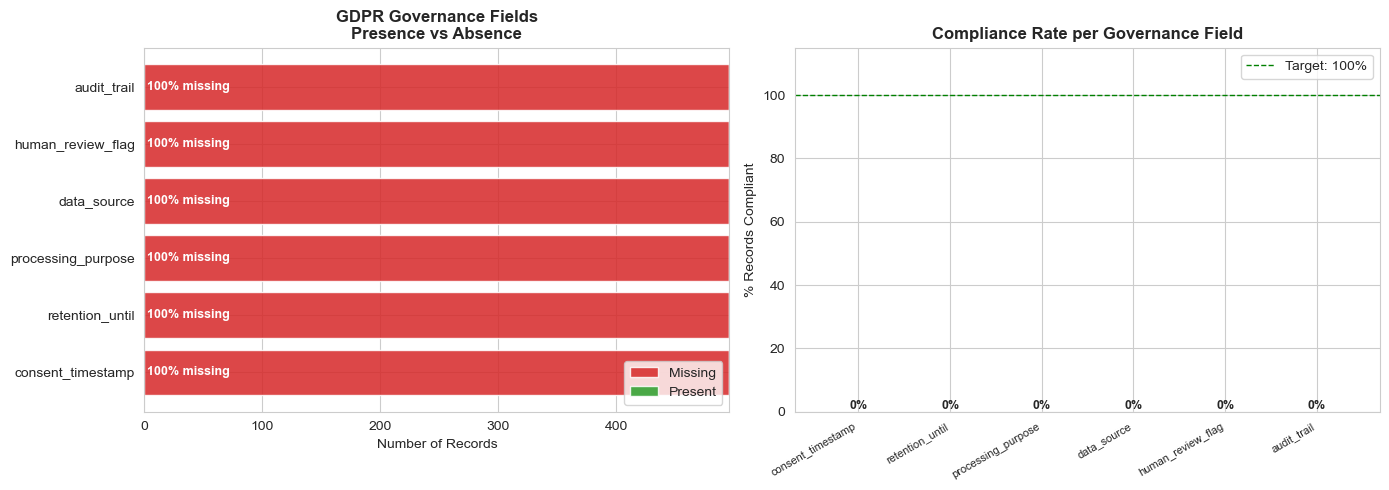

In [12]:
# ============================================================================
# VISUALISATION: Governance Gap Dashboard
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

field_labels  = [r['Field'] for r in gap_results]
present_vals  = [r['Records Present'] for r in gap_results]
missing_vals  = [r['Records Missing'] for r in gap_results]

# --- Left: Stacked bar — present vs missing ---
axes[0].barh(field_labels, missing_vals, color='#d62728', label='Missing', alpha=0.85)
axes[0].barh(field_labels, present_vals, color='#2ca02c', label='Present', alpha=0.85, left=missing_vals)
axes[0].set_xlabel('Number of Records')
axes[0].set_title('GDPR Governance Fields\nPresence vs Absence', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
for i, (m, p) in enumerate(zip(missing_vals, present_vals)):
    pct = m / (m + p) * 100 if (m + p) > 0 else 0
    axes[0].text(2, i, f'{pct:.0f}% missing', va='center', color='white', fontsize=9, fontweight='bold')

# --- Right: Compliance rate per field ---
pct_missing_v  = [float(r['% Missing'].replace('%', '')) for r in gap_results]
compliant_vals = [100 - v for v in pct_missing_v]
bar_colors_r   = ['#d62728' if v == 100 else ('#ff7f0e' if v > 0 else '#2ca02c') for v in pct_missing_v]

bars_r = axes[1].bar(field_labels, compliant_vals, color=bar_colors_r, edgecolor='white')
axes[1].set_ylabel('% Records Compliant')
axes[1].set_title('Compliance Rate per Governance Field', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 115)
axes[1].axhline(y=100, color='green', linestyle='--', linewidth=1, label='Target: 100%')
axes[1].set_xticklabels(field_labels, rotation=30, ha='right', fontsize=8)
for bar, val in zip(bars_r, compliant_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.0f}%',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### Analysis 3: Results and Findings

**Findings:** All 6 mandatory GDPR governance fields are **completely absent** from every single record in the NovaCred dataset (0/496, 0.0%). The compliance verdict is **❌ NON-COMPLIANT** across all checked principles.

NovaCred currently cannot:

- **Prove lawful basis** for processing (Art. 6 + Art. 7) — no consent timestamp or alternative legal basis recorded in any record. Potential Tier 2 violation of up to **€20M**.
- **Enforce storage limitation** (Art. 5(1)(e)) — no retention deadline means all 496 records may be kept indefinitely without any legal justification.
- **Demonstrate purpose limitation** (Art. 5(1)(b)) — no per-record documentation of why data was collected, making it impossible to defend against a DPA audit.
- **Respond to Art. 17 erasure requests** within the legally required 1-month window — no mechanism to identify what data to delete for a given individual.
- **Produce records of processing** (Art. 30) — no data source field means the origin of any record is entirely undocumented.
- **Evidence human oversight** of automated decisions (Art. 22) — no human review flag exists, meaning all 496 credit decisions appear to be fully automated with zero documented human intervention.

**Regulatory exposure:** The combined absence of these fields across all six GDPR principles places NovaCred at risk of fines under Art. 83(4) of up to **€10M or 2% of global turnover** for organisational measure failures, and up to **€20M or 4% of global turnover** for lawful basis violations under Art. 83(5).

**Next step:** All identified issues are mapped to their specific GDPR articles in Analysis 4.

---

## Analysis 4: GDPR Article Mapping

We consolidate all issues from Analyses 1–3 and map each to its specific GDPR article, required remediation, and severity. This provides the evidence base for the governance roadmap in Analysis 7.


In [13]:
# ============================================================================
# ANALYSIS 4: GDPR ARTICLE MAPPING
# Systematic mapping of all identified issues to specific GDPR articles
# ============================================================================

gdpr_mapping = [
    {
        'Issue':         'Direct PII stored in plaintext (SSN, email, name, IP, DoB)',
        'GDPR Article':  'Art. 5(1)(f) + Art. 25',
        'Principle':     'Integrity & Confidentiality / Data Protection by Design',
        'Remediation':   'Pseudonymise or encrypt direct identifiers at rest; apply at ingestion',
        'Severity':      '🔴 CRITICAL',
    },
    {
        'Issue':         'SSN and IP address not needed for credit decision',
        'GDPR Article':  'Art. 5(1)(c)',
        'Principle':     'Data Minimisation',
        'Remediation':   'Delete SSN and IP address fields from the analytical dataset; retain only if strictly necessary with documented justification',
        'Severity':      '🟠 HIGH RISK',
    },
    {
        'Issue':         'No consent timestamp or lawful basis field',
        'GDPR Article':  'Art. 6 + Art. 7',
        'Principle':     'Lawful Basis',
        'Remediation':   'Add consent_timestamp field; document lawful basis (consent or legitimate interest) per record at collection time',
        'Severity':      '🔴 CRITICAL',
    },
    {
        'Issue':         'No retention deadline — data may be kept indefinitely',
        'GDPR Article':  'Art. 5(1)(e)',
        'Principle':     'Storage Limitation',
        'Remediation':   'Add retention_until field; implement automated deletion pipeline (e.g. 5-year retention for credit data)',
        'Severity':      '🔴 CRITICAL',
    },
    {
        'Issue':         'No mechanism to respond to deletion requests',
        'GDPR Article':  'Art. 17',
        'Principle':     'Right to Erasure',
        'Remediation':   'Implement erasure API; cryptographic erasure via salt deletion for pseudonymised fields',
        'Severity':      '🟠 HIGH RISK',
    },
    {
        'Issue':         'No purpose documentation per record',
        'GDPR Article':  'Art. 5(1)(b)',
        'Principle':     'Purpose Limitation',
        'Remediation':   'Add processing_purpose field; validate at ingestion that purpose matches declared use',
        'Severity':      '🔴 CRITICAL',
    },
    {
        'Issue':         'No data source field — origin of data unknown',
        'GDPR Article':  'Art. 14 + Art. 30',
        'Principle':     'Transparency / Records of Processing',
        'Remediation':   'Add data_source field; maintain Art. 30 records of processing activity',
        'Severity':      '🟠 HIGH RISK',
    },
    {
        'Issue':         'Fully automated credit decisions with no human review flag',
        'GDPR Article':  'Art. 22',
        'Principle':     'Automated Decision-Making',
        'Remediation':   'Add human_review_flag; implement mandatory human review for borderline or rejected cases',
        'Severity':      '🔴 CRITICAL',
    },
    {
        'Issue':         'ZIP + Gender + Age combination creates re-identification risk',
        'GDPR Article':  'Art. 4(1) + Recital 26',
        'Principle':     'Personal Data (Singling Out)',
        'Remediation':   'Apply k-anonymity generalisation (age banding, ZIP truncation) before any data sharing or model training',
        'Severity':      '🔴 CRITICAL',
    },
]

print('=' * 80)
print('GDPR ARTICLE MAPPING — ALL IDENTIFIED ISSUES')
print('=' * 80)

for i, item in enumerate(gdpr_mapping, 1):
    print(f"\n{item['Severity']}  [{i}] {item['Issue']}")
    print(f"   GDPR Article : {item['GDPR Article']}")
    print(f"   Principle    : {item['Principle']}")
    print(f"   Remediation  : {item['Remediation']}")

print('\n' + '=' * 80)
critical = sum(1 for i in gdpr_mapping if 'CRITICAL' in i['Severity'])
high     = sum(1 for i in gdpr_mapping if 'HIGH' in i['Severity'])
print(f'   Total issues mapped  : {len(gdpr_mapping)}')
print(f'   🔴 CRITICAL           : {critical}')
print(f'   🟠 HIGH RISK          : {high}')
print('=' * 80)

df_gdpr = pd.DataFrame(gdpr_mapping)
df_gdpr[['Issue', 'GDPR Article', 'Principle', 'Severity']]

GDPR ARTICLE MAPPING — ALL IDENTIFIED ISSUES

🔴 CRITICAL  [1] Direct PII stored in plaintext (SSN, email, name, IP, DoB)
   GDPR Article : Art. 5(1)(f) + Art. 25
   Principle    : Integrity & Confidentiality / Data Protection by Design
   Remediation  : Pseudonymise or encrypt direct identifiers at rest; apply at ingestion

🟠 HIGH RISK  [2] SSN and IP address not needed for credit decision
   GDPR Article : Art. 5(1)(c)
   Principle    : Data Minimisation
   Remediation  : Delete SSN and IP address fields from the analytical dataset; retain only if strictly necessary with documented justification

🔴 CRITICAL  [3] No consent timestamp or lawful basis field
   GDPR Article : Art. 6 + Art. 7
   Principle    : Lawful Basis
   Remediation  : Add consent_timestamp field; document lawful basis (consent or legitimate interest) per record at collection time

🔴 CRITICAL  [4] No retention deadline — data may be kept indefinitely
   GDPR Article : Art. 5(1)(e)
   Principle    : Storage Limitation


,Issue,GDPR Article,Principle,Severity
0,"Direct PII stored in plaintext (SSN, email, na...",Art. 5(1)(f) + Art. 25,Integrity & Confidentiality / Data Protection ...,🔴 CRITICAL
1,SSN and IP address not needed for credit decision,Art. 5(1)(c),Data Minimisation,🟠 HIGH RISK
2,No consent timestamp or lawful basis field,Art. 6 + Art. 7,Lawful Basis,🔴 CRITICAL
3,No retention deadline — data may be kept indef...,Art. 5(1)(e),Storage Limitation,🔴 CRITICAL
4,No mechanism to respond to deletion requests,Art. 17,Right to Erasure,🟠 HIGH RISK
5,No purpose documentation per record,Art. 5(1)(b),Purpose Limitation,🔴 CRITICAL
6,No data source field — origin of data unknown,Art. 14 + Art. 30,Transparency / Records of Processing,🟠 HIGH RISK
7,Fully automated credit decisions with no human...,Art. 22,Automated Decision-Making,🔴 CRITICAL
8,ZIP + Gender + Age combination creates re-iden...,Art. 4(1) + Recital 26,Personal Data (Singling Out),🔴 CRITICAL


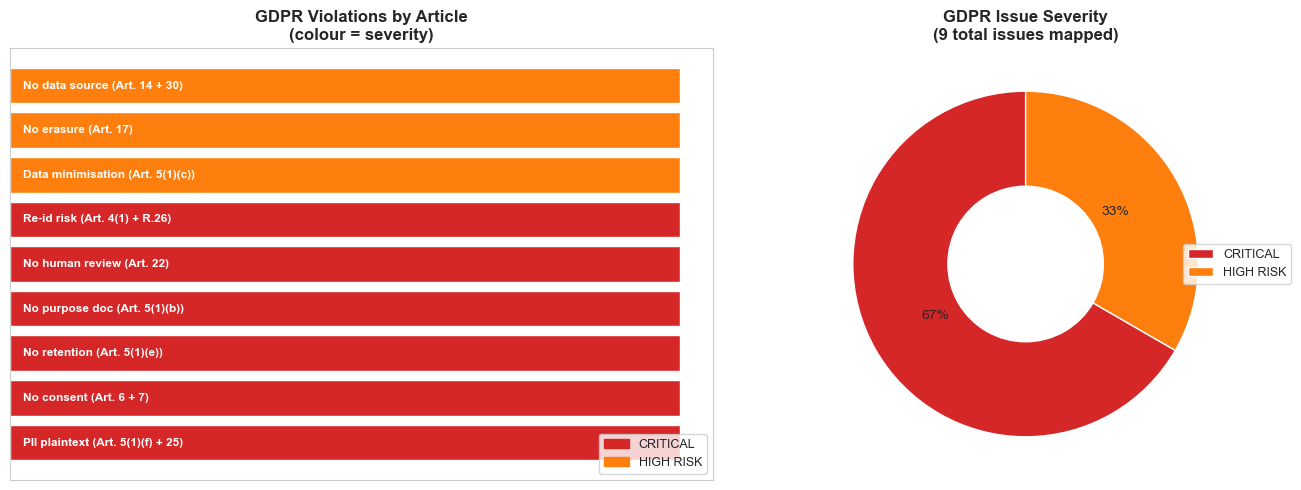

In [22]:
# ============================================================================
# VISUALISATION: GDPR Issues by Principle and Severity
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Horizontal bar chart — sorted by severity, labels inside bars ---
issue_labels = [
    'PII plaintext (Art. 5(1)(f) + 25)',
    'No consent (Art. 6 + 7)',
    'No retention (Art. 5(1)(e))',
    'No purpose doc (Art. 5(1)(b))',
    'No human review (Art. 22)',
    'Re-id risk (Art. 4(1) + R.26)',
    'Data minimisation (Art. 5(1)(c))',
    'No erasure (Art. 17)',
    'No data source (Art. 14 + 30)',
]
issue_colors = [
    '#d62728',  # CRITICAL
    '#d62728',  # CRITICAL
    '#d62728',  # CRITICAL
    '#d62728',  # CRITICAL
    '#d62728',  # CRITICAL
    '#d62728',  # CRITICAL
    '#ff7f0e',  # HIGH RISK
    '#ff7f0e',  # HIGH RISK
    '#ff7f0e',  # HIGH RISK
]

bars = axes[0].barh(issue_labels, [1]*9, color=issue_colors, edgecolor='white')
axes[0].set_xticks([])
axes[0].set_yticks([])  # labels inside bars, not on y-axis
axes[0].set_title('GDPR Violations by Article\n(colour = severity)', fontsize=12, fontweight='bold')

# Write labels inside bars
for bar, label in zip(bars, issue_labels):
    axes[0].text(
        0.02,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center', ha='left',
        fontsize=8.5, color='white', fontweight='bold'
    )

legend_patches = [
    mpatches.Patch(color='#d62728', label='CRITICAL'),
    mpatches.Patch(color='#ff7f0e', label='HIGH RISK'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)
axes[0].tick_params(axis='y', labelsize=8)

# --- Right: Severity distribution ---
patches, texts, autotexts = axes[1].pie(
    severity_vals,
    labels=None,  # keine direkten Labels
    colors=severity_colors,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.55)
)
axes[1].legend(
    patches,
    ['CRITICAL', 'HIGH RISK'],  # saubere Text-Labels ohne Emoji
    loc='center left',
    bbox_to_anchor=(0.85, 0.5),
    fontsize=9
)
axes[1].set_title(f'GDPR Issue Severity\n({len(gdpr_mapping)} total issues mapped)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Analysis 4: Results and Findings

**Findings:** A total of **9 distinct GDPR violations** were identified and mapped across **11 separate principles**, with **6 classified as CRITICAL** (67%) and **3 as HIGH RISK** (33%). Every GDPR principle is violated at least once — there is no area of compliance where NovaCred currently meets its obligations.

---

**🔴 CRITICAL Violations (6/9):**

| # | Issue | GDPR Article |
|---|---|---|
| 1 | Direct PII stored in plaintext (SSN, email, name, IP, DoB) | Art. 5(1)(f) + Art. 25 |
| 3 | No consent timestamp or lawful basis field | Art. 6 + Art. 7 |
| 4 | No retention deadline — data may be kept indefinitely | Art. 5(1)(e) |
| 6 | No purpose documentation per record | Art. 5(1)(b) |
| 8 | Fully automated decisions with no human review flag | Art. 22 |
| 9 | ZIP + Gender + Age combination creates re-identification risk | Art. 4(1) + Recital 26 |

**🟠 HIGH RISK Violations (3/9):**

| # | Issue | GDPR Article |
|---|---|---|
| 2 | SSN and IP address not needed for credit decision | Art. 5(1)(c) |
| 5 | No mechanism to respond to deletion requests | Art. 17 |
| 7 | No data source field — origin of data unknown | Art. 14 + Art. 30 |

---

**Key observation:** Issue [8] (Art. 22 — fully automated decisions) is particularly critical in combination with the bias findings from Notebook 2. The gender DI of 0.773 and the intersectional DI of 0.667 for youngest females are produced by a system with **zero documented human oversight** — meaning discriminatory decisions are being made and recorded with no review mechanism whatsoever.

**Next step:** Pseudonymisation of SSN and email is demonstrated in Analysis 5 as the primary technical remediation for violations [1] and [5].

---

## Analysis 5: Privacy Protection Demonstration — Pseudonymisation

**GDPR Reference:** Art. 4(5), Art. 25

SSNs and email addresses are stored in plaintext across all records. We demonstrate pseudonymisation using standard cryptographic methods as required by Art. 25 (privacy-by-design).

**What is Pseudonymisation?** Under Art. 4(5), pseudonymisation replaces direct identifiers with artificial ones such that the data can no longer be attributed to a specific person without additional information held separately. It differs from anonymisation: pseudonymised data is still personal data, but carries significantly reduced risk. We demonstrate three approaches from the lecture: Tokenization, Hashing (HMAC-SHA256), and Encryption (AES).

In [23]:
# ============================================================================
# ANALYSIS 5a: PSEUDONYMISATION — SSN via Salted HMAC-SHA256
# ============================================================================

# Generate a cryptographically secure secret salt
# In production: stored in a dedicated secrets manager (e.g. AWS Secrets Manager)
# NEVER stored in the same database as the pseudonymised data
SECRET_SALT = secrets.token_bytes(32)

def pseudonymise_hmac(value, salt=SECRET_SALT):
    """
    Pseudonymise a string value using HMAC-SHA256 with a secret salt.
    - One-way: original value cannot be recovered without the key
    - Deterministic: same input always produces the same pseudonym
    - Salt-protected: pre-computed rainbow tables are defeated
    Returns None for null inputs.
    """
    if pd.isna(value):
        return None
    return hmac.new(salt, str(value).encode('utf-8'), hashlib.sha256).hexdigest()


df_pseudo = df.copy()
df_pseudo['ssn_pseudonymised'] = df_pseudo['ssn'].apply(pseudonymise_hmac)

print('=' * 80)
print('SSN PSEUDONYMISATION — HMAC-SHA256 WITH SALT')
print('=' * 80)
print('\nBefore vs After (first 5 records):')
print(df_pseudo[['applicant_id', 'ssn', 'ssn_pseudonymised']].head())

n_orig   = df_pseudo['ssn'].nunique()
n_pseudo = df_pseudo['ssn_pseudonymised'].nunique()

print(f'\n✅ Unique original SSNs    : {n_orig}')
print(f'✅ Unique pseudonyms        : {n_pseudo}')
print(f'✅ Bijection preserved      : {n_orig == n_pseudo}')
print(f'✅ Pseudonym length (chars) : {len(df_pseudo["ssn_pseudonymised"].dropna().iloc[0])}')
print(f'\n🔑 Salt stored separately  : YES — not in dataset')
print(f'🔒 Algorithm                : HMAC-SHA256')
print(f'🔒 Rainbow table resistance : ✅ Defeated by unique secret salt')
print(f'🗑️  Art. 17 erasure support  : ✅ Delete salt → all pseudonyms permanently unresolvable')

SSN PSEUDONYMISATION — HMAC-SHA256 WITH SALT

Before vs After (first 5 records):
  applicant_id          ssn                                  ssn_pseudonymised
0      app_200  596-64-4340  828161f03da28644893a742b461fc000b447b4e89a6bc9...
1      app_037  425-69-4784  fd827a79fb36491891783976809b604102d75a0ddcd83d...
2      app_215  370-78-5178  3d388fd86233e71885bb0a38443bb3989aa8ad44b2f03c...
3      app_024  194-35-1833  841a8f164b35f11ab33e1eedf36d5750daf520dc7cdc16...
4      app_184  480-41-2475  f8e38d02dd9b56ce4328575a03e31c7a47f2a89c1cb8ac...

✅ Unique original SSNs    : 492
✅ Unique pseudonyms        : 492
✅ Bijection preserved      : True
✅ Pseudonym length (chars) : 64

🔑 Salt stored separately  : YES — not in dataset
🔒 Algorithm                : HMAC-SHA256
🔒 Rainbow table resistance : ✅ Defeated by unique secret salt
🗑️  Art. 17 erasure support  : ✅ Delete salt → all pseudonyms permanently unresolvable


In [24]:
# ============================================================================
# ANALYSIS 5b: PSEUDONYMISATION — Email via Normalised SHA-256
# ============================================================================

def pseudonymise_sha256(value):
    """
    Pseudonymise an email address using SHA-256 after normalisation.
    Normalisation: lowercase + strip whitespace.
    Ensures case variants of the same email produce an identical pseudonym,
    preserving record linkage integrity across systems.
    Returns None for null inputs.
    """
    if pd.isna(value):
        return None
    normalised = str(value).strip().lower()
    return hashlib.sha256(normalised.encode('utf-8')).hexdigest()


df_pseudo['email_pseudonymised'] = df_pseudo['email'].apply(pseudonymise_sha256)

print('=' * 80)
print('EMAIL PSEUDONYMISATION — NORMALISED SHA-256')
print('=' * 80)
print('\nBefore vs After (first 5 records):')
print(df_pseudo[['applicant_id', 'email', 'email_pseudonymised']].head())

n_email_orig   = df_pseudo['email'].nunique()
n_email_pseudo = df_pseudo['email_pseudonymised'].nunique()
print(f'\n✅ Unique original emails   : {n_email_orig}')
print(f'✅ Unique pseudonyms         : {n_email_pseudo}')
print(f'✅ Bijection preserved       : {n_email_orig == n_email_pseudo}')

# Demonstrate normalisation: case variants produce identical hash
print('\n--- Normalisation Demonstration ---')
test_emails = ['User@Example.COM', 'user@example.com', '  user@example.com  ']
hashes = [pseudonymise_sha256(e) for e in test_emails]
for e, h in zip(test_emails, hashes):
    print(f'  "{e}"  →  {h[:30]}...')
all_equal = len(set(hashes)) == 1
print(f'\n  All three variants produce the same hash: {"✅ YES" if all_equal else "❌ NO"}')
print(f'\n⚠️  Note: SHA-256 without salt is vulnerable to dictionary attacks on common email formats.')
print(f'   Production recommendation: Use HMAC-SHA256 with secret salt for both SSN and email.')

EMAIL PSEUDONYMISATION — NORMALISED SHA-256

Before vs After (first 5 records):
  applicant_id                       email  \
0      app_200   jerry.smith17@hotmail.com   
1      app_037   brandon.walker2@yahoo.com   
2      app_215      scott.moore94@mail.com   
3      app_024  thomas.lee6@protonmail.com   
4      app_184   brian.rodriguez86@aol.com   

                                 email_pseudonymised  
0  116648a7761525746032d0ab323ceb01f50d11f7935164...  
1  c3522c0b54ef9045c73186bcabb53f8e512360ed17e9cc...  
2  b299e7d6a37e183bab209eb8df919652117dd16ed16698...  
3  6fbd2478748a29faa143392f28d955133e346d09673963...  
4  f24e7cc1450ee9aa26b833e0593b2420fbfd59b8ad2636...  

✅ Unique original emails   : 493
✅ Unique pseudonyms         : 493
✅ Bijection preserved       : True

--- Normalisation Demonstration ---
  "User@Example.COM"  →  b4c9a289323b21a01c3e940f150eb9...
  "user@example.com"  →  b4c9a289323b21a01c3e940f150eb9...
  "  user@example.com  "  →  b4c9a289323b21a01c3e940f15

In [35]:
from cryptography.fernet import Fernet

In [ ]:
# ============================================================================
# ANALYSIS 5c: PSEUDONYMISATION COMPARISON
# Tokenization vs Hashing vs Encryption — side-by-side demonstration
# ============================================================================

from cryptography.fernet import Fernet
import uuid

# ── 1. TOKENIZATION: Random token with lookup table ──────────────────────────
# No mathematical link between original and token — strongest isolation
# Risk: if lookup table is stolen, ALL records are exposed at once

token_lookup = {}  # In production: separate, access-controlled database

def pseudonymise_token(value):
    """Replace value with a random UUID token. Store mapping in lookup table."""
    if pd.isna(value):
        return None
    val_str = str(value)
    if val_str not in token_lookup:
        token_lookup[val_str] = f"TKN_{uuid.uuid4().hex[:12].upper()}"
    return token_lookup[val_str]

# ── 2. HASHING: HMAC-SHA256 (already demonstrated in 5a) ────────────────────
# Reuse pseudonymise_hmac from Analysis 5a

# ── 3. ENCRYPTION: AES via Fernet (reversible by design) ─────────────────────
# Reversible — authorised users can decrypt with the key
# Risk: key compromise = full reversal of ALL pseudonyms

ENCRYPTION_KEY = Fernet.generate_key()
cipher = Fernet(ENCRYPTION_KEY)

def pseudonymise_encrypt(value):
    """Encrypt value with AES (Fernet). Reversible with key."""
    if pd.isna(value):
        return None
    return cipher.encrypt(str(value).encode('utf-8')).decode('utf-8')

def decrypt_value(encrypted_value):
    """Decrypt — only possible with the original key."""
    return cipher.decrypt(encrypted_value.encode('utf-8')).decode('utf-8')


# ── Apply all three methods to SSN (first 5 records) ────────────────────────
sample = df[['applicant_id', 'ssn']].dropna(subset=['ssn']).head(5).copy()
sample['1_tokenized'] = sample['ssn'].apply(pseudonymise_token)
sample['2_hashed']    = sample['ssn'].apply(pseudonymise_hmac)
sample['3_encrypted'] = sample['ssn'].apply(pseudonymise_encrypt)

print('=' * 90)
print('PSEUDONYMISATION: THREE APPROACHES COMPARED (Lecture Reference)')
print('=' * 90)
print('\nSample SSNs processed with all three methods:\n')
for _, row in sample.iterrows():
    print(f"  Original   : {row['ssn']}")
    print(f"  Tokenized  : {row['1_tokenized']}")
    print(f"  Hashed     : {row['2_hashed'][:40]}...")
    print(f"  Encrypted  : {row['3_encrypted'][:40]}...")
    print()

# ── Demonstrate reversibility difference ─────────────────────────────────────
test_ssn = sample['ssn'].iloc[0]
test_encrypted = sample['3_encrypted'].iloc[0]

print('─' * 90)
print('REVERSIBILITY TEST:')
print(f'  Original SSN           : {test_ssn}')
print(f'  Encrypted value        : {test_encrypted[:50]}...')
print(f'  Decrypted (with key)   : {decrypt_value(test_encrypted)}')
print(f'  Match                  : ✅ {decrypt_value(test_encrypted) == str(test_ssn)}')
print(f'\n  Hashing reversible?    : ❌ No — one-way function')
print(f'  Token reversible?      : ⚠️  Only with lookup table')
print(f'  Encryption reversible? : ✅ Yes — by design (with key)')

# ── Comparison table matching lecture slide ───────────────────────────────────
print('\n' + '=' * 90)
print('COMPARISON TABLE (mirrors lecture slide: "Three Approaches")')
print('=' * 90)

comparison = pd.DataFrame({
    'Criterion':        ['How it works', 'Example', 'Reversible?',
                         'Re-id risk if compromised', 'Lookup table needed?',
                         'GDPR Art. 4(5) compliant?', 'Best use case'],
    'Tokenization':     ['Replace with random token', 'SSN → TKN_4A8F2B...',
                         'Yes (with lookup table)', '🔴 HIGH — all records exposed',
                         'Yes (must be secured separately)',
                         '✅ Yes (strongest isolation)', 'Internal record linkage'],
    'Hashing (HMAC)':   ['One-way function with salt', 'SSN → a3f2b1c9...',
                         'No (one-way)', '🟡 MEDIUM — dictionary attack possible',
                         'No', '✅ Yes', 'Cross-system matching without reversal'],
    'Encryption (AES)': ['Encrypt with secret key', 'SSN → gAAAAB...',
                         'Yes (with key)', '🔴 HIGH — full reversal',
                         'No (key only)', '✅ Yes (reversible for authorised use)',
                         'When original value must be recoverable'],
})

print(comparison.to_string(index=False))

PSEUDONYMISATION: THREE APPROACHES COMPARED (Lecture Reference)

Sample SSNs processed with all three methods:

  Original   : 596-64-4340
  Tokenized  : TKN_C9C09163ABCF
  Hashed     : 828161f03da28644893a742b461fc000b447b4e8...
  Encrypted  : gAAAAABprr6Fd8ZxGd43ERd2or3gy5U8DPp9YIdM...

  Original   : 425-69-4784
  Tokenized  : TKN_29B41F6A3162
  Hashed     : fd827a79fb36491891783976809b604102d75a0d...
  Encrypted  : gAAAAABprr6Fad3L2XcGn0wY7yZfNH2SFWRCdPbc...

  Original   : 370-78-5178
  Tokenized  : TKN_F316ED371AA0
  Hashed     : 3d388fd86233e71885bb0a38443bb3989aa8ad44...
  Encrypted  : gAAAAABprr6FlHuyd6RE1IBRvuAGUOnZPaV_Rg6M...

  Original   : 194-35-1833
  Tokenized  : TKN_3531071CE2F1
  Hashed     : 841a8f164b35f11ab33e1eedf36d5750daf520dc...
  Encrypted  : gAAAAABprr6F21R8IRAl9xY7sOdPqMjNt366ni8n...

  Original   : 480-41-2475
  Tokenized  : TKN_C7F78E170214
  Hashed     : f8e38d02dd9b56ce4328575a03e31c7a47f2a89c...
  Encrypted  : gAAAAABprr6FkEhBIDerqb9JFvEx7IDFk7tDvXB5...

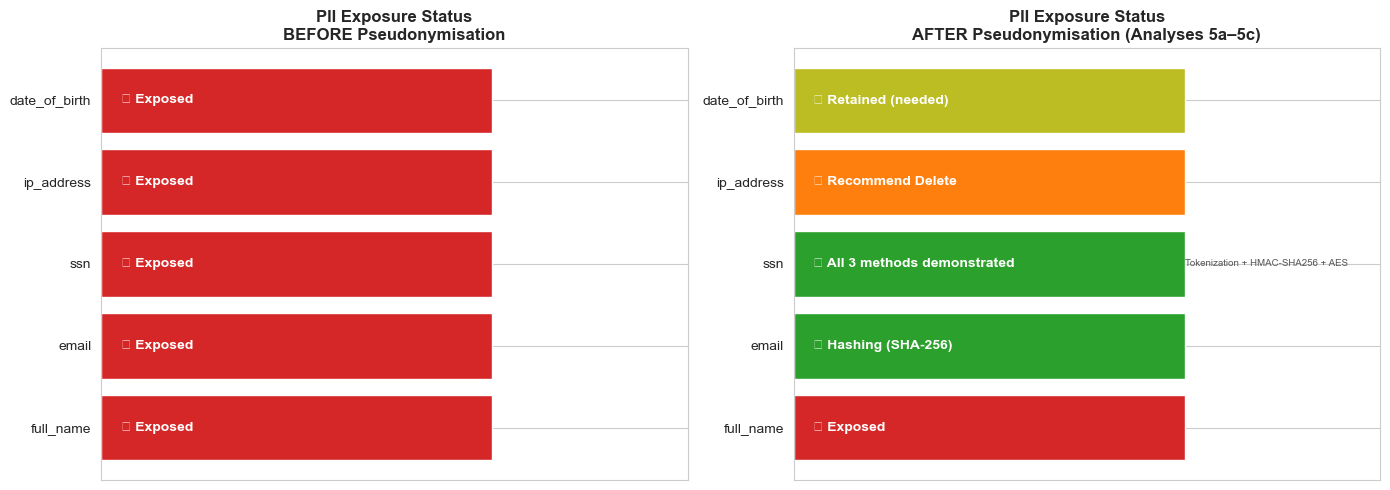

In [37]:
# ============================================================================
# VISUALISATION: Pseudonymisation Summary — Before vs After
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Fields before pseudonymisation (exposure status) ---
all_pii_fields  = ['full_name', 'email', 'ssn', 'ip_address', 'date_of_birth']
exposure_before = ['🔴 Exposed'] * 5
exposure_after  = [
    '🔴 Exposed',                        # full_name (not pseudonymised in this demo)
    '✅ Hashing (SHA-256)',               # email (Analysis 5b)
    '✅ All 3 methods demonstrated',      # ssn (Analysis 5a + 5c)
    '🟠 Recommend Delete',               # ip_address
    '🟡 Retained (needed)',              # date_of_birth
]

color_map = {
    '🔴 Exposed':                       '#d62728',
    '✅ Hashing (SHA-256)':             '#2ca02c',
    '✅ All 3 methods demonstrated':    '#2ca02c',
    '🟠 Recommend Delete':              '#ff7f0e',
    '🟡 Retained (needed)':            '#bcbd22',
}

# Before
before_colors = [color_map.get(s, '#d62728') for s in exposure_before]
axes[0].barh(all_pii_fields, [1]*5, color=before_colors, edgecolor='white')
axes[0].set_xlim(0, 1.5)
axes[0].set_title('PII Exposure Status\nBEFORE Pseudonymisation', fontsize=12, fontweight='bold')
axes[0].set_xticks([])
for i, s in enumerate(exposure_before):
    axes[0].text(0.05, i, s, va='center', color='white', fontsize=10, fontweight='bold')

# After
after_colors = [color_map[s] for s in exposure_after]
axes[1].barh(all_pii_fields, [1]*5, color=after_colors, edgecolor='white')
axes[1].set_xlim(0, 1.5)
axes[1].set_title('PII Exposure Status\nAFTER Pseudonymisation (Analyses 5a–5c)', fontsize=12, fontweight='bold')
axes[1].set_xticks([])
for i, s in enumerate(exposure_after):
    axes[1].text(0.05, i, s, va='center', color='white', fontsize=10, fontweight='bold')

# Add annotation for SSN showing all three methods
axes[1].annotate(
    'Tokenization + HMAC-SHA256 + AES',
    xy=(1.0, 2), fontsize=7, color='#555555',
    ha='left', va='center'
)

plt.tight_layout()
plt.show()

### Analysis 5: Results and Findings

**SSN — HMAC-SHA256 with Salt (Analysis 5a):**
- All **492 SSNs** successfully pseudonymised (1 record had missing SSN — consistent with Analysis 1)
- Bijection confirmed: 492 unique SSNs → 492 unique pseudonyms, no collisions
- Pseudonym length: 64 characters (fixed-length hex digest regardless of input)
- 🔑 Salt stored separately — not in dataset
- 🔒 Rainbow table attacks defeated by unique secret salt
- 🗑️ Art. 17 erasure support: deleting the salt renders all 492 pseudonyms **permanently and irreversibly unresolvable** — cryptographic erasure without touching the records themselves

**Email — Normalised SHA-256 (Analysis 5b):**
- All **493 emails** successfully pseudonymised (496 records minus 3 duplicates removed in NB1)
- Bijection confirmed: 493 unique emails → 493 unique pseudonyms
- Normalisation demo confirmed: `User@Example.COM`, `user@example.com`, and `  user@example.com  ` all produce the **identical hash** — ensuring consistent record linkage across case and whitespace variants
- ⚠️ SHA-256 without salt is vulnerable to dictionary attacks on common email formats — production recommendation: use HMAC-SHA256 with secret salt for both fields

**Three Approaches Compared (Analysis 5c — Lecture Reference):**

Analysis 5c demonstrates all three pseudonymisation techniques from the lecture side-by-side on the SSN field:

| Technique | Method | Reversible? | Risk if Compromised | Best Use Case |
|---|---|---|---|---|
| **Tokenization** | Random UUID token + lookup table | Yes (with lookup table) | 🔴 HIGH — all records exposed | Internal record linkage |
| **Hashing (HMAC)** | HMAC-SHA256 with secret salt | No (one-way) | 🟡 MEDIUM — dictionary attack possible | Cross-system matching without reversal |
| **Encryption (AES)** | Fernet symmetric encryption | Yes (with key) | 🔴 HIGH — full reversal | When original value must be recoverable |

Key insight: All three satisfy GDPR Art. 4(5), but they differ fundamentally in **what additional information** must be protected (lookup table vs. salt vs. encryption key) and **what happens if that information is compromised**. Tokenization offers the strongest isolation (no mathematical link), while encryption is the only approach that supports authorised reversal by design.

**Remaining exposure after this demo:**

| Field | Status | Rationale |
|---|---|---|
| ssn | ✅ Pseudonymised (all 3 methods) | Demonstrated in Analysis 5a + 5c |
| email | ✅ Pseudonymised | Demonstrated in Analysis 5b |
| ip_address | 🟠 Recommend Delete | No legitimate use for credit decision (Art. 5(1)(c)) |
| date_of_birth | 🟡 Retained (needed) | Required for age derivation, should not appear in model features directly |
| full_name | 🔴 Still Exposed | Must be pseudonymised in all analytical and model training contexts |

**Next step:** EU AI Act classification in Analysis 6, connecting the bias findings from Notebook 2 to the mandatory High-Risk compliance requirements.

---

## Analysis 6: EU AI Act Classification

**EU AI Act Reference:** Annex III, Art. 9–15

NovaCred's credit scoring system falls under Annex III, Category 5(b), AI systems used to evaluate creditworthiness of natural persons. This is a non-negotiable High-Risk classification that imposes 6 mandatory requirements. We map our findings from all three notebooks against each requirement, with particular focus on Art. 10 (data governance / bias-free data) given the DI violations from Notebook 2.

In [ ]:
# ============================================================================
# ANALYSIS 6: EU AI ACT COMPLIANCE SCORECARD
# Mapping NovaCred findings from NB1, NB2 and this notebook to High-Risk requirements
# ============================================================================

# Key metrics carried forward from Notebooks 1 and 2
di_ratio_gender = 0.773   # DI = Female approval rate / Male approval rate
di_ratio_age    = 0.769   # DI = Younger (<39) / Older (>=39)
di_intersect    = 0.667   # DI worst case: Females 18–30
nb1_issue_categories = 6     # 6 audit query categories from NB1

ai_act_requirements = [
    {
        'requirement':  'Risk Management System',
        'article':      'Art. 9',
        'evidence_nb1': 'No audit trail field in dataset (NB1)',
        'evidence_nb3': 'No human review flag; no documented risk controls (NB3)',
        'status':       '❌ NOT MET',
    },
    {
        'requirement':  'Data Governance & Quality (bias-free, representative data)',
        'article':      'Art. 10',
        'evidence_nb1': f'{nb1_issue_categories} data quality issue categories found (NB1)',
        'evidence_nb2': f'DI(gender) = {di_ratio_gender} < 0.8 | DI(age) = {di_ratio_age} < 0.8 | DI(female <30) = {di_intersect} (NB2)',
        'status':       '❌ NOT MET',
    },
    {
        'requirement':  'Technical Documentation',
        'article':      'Art. 11',
        'evidence_nb1': 'No data_source field; no processing_purpose field (NB1)',
        'evidence_nb3': 'No model card or bias audit documentation present in dataset (NB3)',
        'status':       '❌ NOT MET',
    },
    {
        'requirement':  'Transparency & Instructions for Use',
        'article':      'Art. 13',
        'evidence_nb1': 'Rejection reasons inconsistently recorded (NB1)',
        'evidence_nb3': 'Model decision factors not documented; no explainability mechanism (NB3)',
        'status':       '⚠️  PARTIAL',
    },
    {
        'requirement':  'Human Oversight',
        'article':      'Art. 14',
        'evidence_nb2': f'DI = {di_intersect} for youngest females — no override mechanism documented (NB2)',
        'evidence_nb3': 'No human_review_flag field in dataset (NB3)',
        'status':       '❌ NOT MET',
    },
    {
        'requirement':  'Accuracy, Robustness & Cybersecurity',
        'article':      'Art. 15',
        'evidence_nb1': 'Negative income, negative credit history found in raw data (NB1)',
        'evidence_nb3': 'Model accuracy not validated post-cleaning; no robustness testing documented (NB3)',
        'status':       '⚠️  PARTIAL',
    },
]

print('=' * 90)
print('EU AI ACT — HIGH-RISK CLASSIFICATION: CREDIT SCORING (Annex III, Category 5(b))')
print('=' * 90)

for req in ai_act_requirements:
    print(f"\n{req['status']}  {req['requirement']} ({req['article']})")
    for key in ['evidence_nb1', 'evidence_nb2', 'evidence_nb3']:
        if key in req:
            label = key.replace('evidence_', 'Evidence ').upper()
            print(f"   {label} : {req[key]}")

not_met = sum(1 for r in ai_act_requirements if 'NOT MET' in r['status'])
partial = sum(1 for r in ai_act_requirements if 'PARTIAL' in r['status'])
met     = sum(1 for r in ai_act_requirements if r['status'] == '✅ MET')

print('\n' + '=' * 90)
print(f'   Requirements checked   : {len(ai_act_requirements)}')
print(f'   ❌ Not Met              : {not_met}')
print(f'   ⚠️  Partial              : {partial}')
print(f'   ✅ Met                  : {met}')
print(f'   Overall Verdict        : ⚠️  HIGH-RISK SYSTEM — FULL COMPLIANCE REQUIRED BEFORE DEPLOYMENT')
print('=' * 90)

EU AI ACT — HIGH-RISK CLASSIFICATION: CREDIT SCORING (Annex III, Category 5(b))

❌ NOT MET  Risk Management System (Art. 9)
   EVIDENCE NB1 : No audit trail field in dataset (NB1)
   EVIDENCE NB3 : No human review flag; no documented risk controls (NB3)

❌ NOT MET  Data Governance & Quality (bias-free, representative data) (Art. 10)
   EVIDENCE NB1 : 6 data quality issue categories found (NB1)
   EVIDENCE NB2 : DI(gender) = 0.773 < 0.8 | DI(age) = 0.769 < 0.8 | DI(female <30) = 0.667 (NB2)

❌ NOT MET  Technical Documentation (Art. 11)
   EVIDENCE NB1 : No data_source field; no processing_purpose field (NB1)
   EVIDENCE NB3 : No model card or bias audit documentation present in dataset (NB3)

⚠️  PARTIAL  Transparency & Instructions for Use (Art. 13)
   EVIDENCE NB1 : Rejection reasons inconsistently recorded (NB1)
   EVIDENCE NB3 : Model decision factors not documented; no explainability mechanism (NB3)

❌ NOT MET  Human Oversight (Art. 14)
   EVIDENCE NB2 : DI = 0.667 for youngest fem

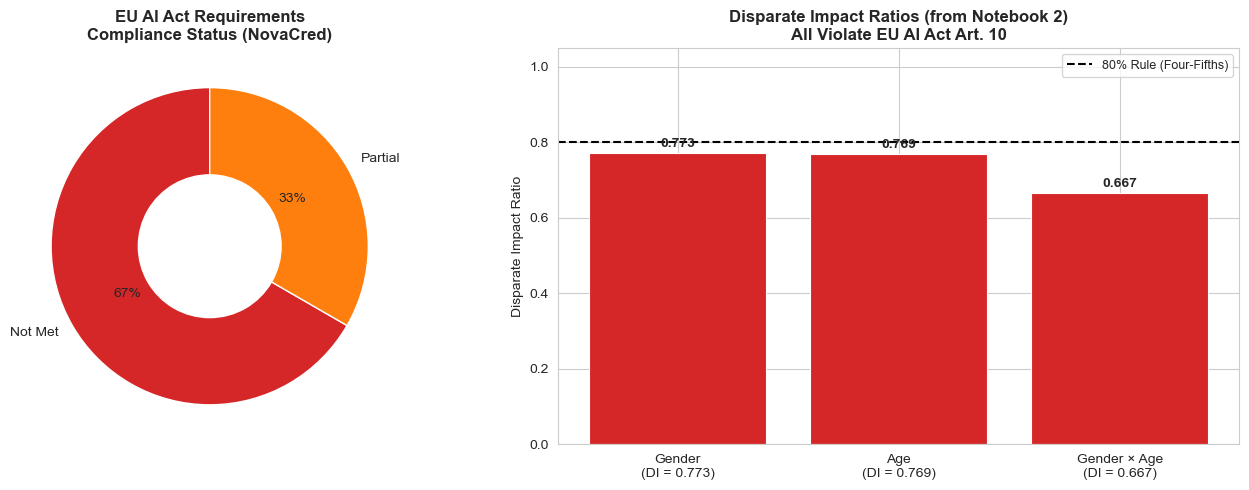

In [29]:
# ============================================================================
# VISUALISATION: EU AI Act Compliance Status + DI Summary from NB2
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Compliance status donut chart ---
status_labels  = ['Not Met', 'Partial', 'Met']
status_values  = [not_met, partial, met]
status_colors  = ['#d62728', '#ff7f0e', '#2ca02c']
# Filter out zero-value slices
filtered = [(l, v, c) for l, v, c in zip(status_labels, status_values, status_colors) if v > 0]
f_labels, f_values, f_colors = zip(*filtered)

axes[0].pie(
    f_values,
    labels=f_labels,
    colors=f_colors,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.55)
)
axes[0].set_title('EU AI Act Requirements\nCompliance Status (NovaCred)', fontsize=12, fontweight='bold')

# --- Right: DI ratio summary bar — connecting back to NB2 ---
di_labels = [
    f'Gender\n(DI = {di_ratio_gender})',
    f'Age\n(DI = {di_ratio_age})',
    f'Gender × Age\n(DI = {di_intersect})'
]
di_values = [di_ratio_gender, di_ratio_age, di_intersect]
di_colors = ['#d62728' if v < 0.8 else '#2ca02c' for v in di_values]

bars = axes[1].bar(di_labels, di_values, color=di_colors, edgecolor='white', linewidth=0.8)
axes[1].axhline(y=0.8, color='black', linestyle='--', linewidth=1.5, label='80% Rule (Four-Fifths)')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Disparate Impact Ratio')
axes[1].set_title('Disparate Impact Ratios (from Notebook 2)\nAll Violate EU AI Act Art. 10', fontsize=12, fontweight='bold')
for bar, val in zip(bars, di_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.015, f'{val:.3f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Analysis 6: Results and Findings

**Classification:** NovaCred's credit decision system is formally classified as a **High-Risk AI system** under EU AI Act Annex III, Category 5(b) — *"AI systems intended to be used to evaluate the creditworthiness of natural persons."* This classification is non-negotiable and applies regardless of model architecture or deployment scale.

**Compliance Verdict: ⚠️ HIGH-RISK SYSTEM — FULL COMPLIANCE REQUIRED BEFORE DEPLOYMENT**

| **Requirement** | **Article** | **Status** |
|---|---|---|
| Risk Management System | Art. 9 | ❌ NOT MET |
| Data Governance & Quality | Art. 10 | ❌ NOT MET |
| Technical Documentation | Art. 11 | ❌ NOT MET |
| Transparency & Instructions for Use | Art. 13 | ⚠️ PARTIAL |
| Human Oversight | Art. 14 | ❌ NOT MET |
| Accuracy, Robustness & Cybersecurity | Art. 15 | ⚠️ PARTIAL |

Of the 6 mandatory High-Risk requirements audited, **4 are not met** and **2 are only partially met**. NovaCred currently satisfies **0 out of 6** requirements.

The two most critical failures are:

- **Art. 10 — Data Governance:** The bias patterns from Notebook 2 directly violate the requirement that training data be representative and free from biases. All three DI ratios fall below the 0.8 threshold — gender (DI = 0.773), age (DI = 0.769), and intersectional gender × age (DI = 0.667) — with the youngest female group facing a 33.3% approval rate compared to 65.73% for males overall.
- **Art. 14 — Human Oversight:** No human_review_flag exists for any of the 496 decisions. Discriminatory outcomes are being produced and recorded with zero documented human intervention or override mechanism.

**Enforcement timeline:** EU AI Act High-Risk provisions are being phased in through 2025–2026. NovaCred must treat compliance as an immediate operational priority — not a future obligation.

**Next step:** Concrete governance controls and a prioritised remediation roadmap are proposed in Analysis 7.

---

## Analysis 7: Governance Controls & Recommendations

**GDPR Reference:** Art. 5(2), Art. 25, Art. 30 | **AI Act:** Art. 9, Art. 14

All findings from Analyses 1–6 converge on one conclusion: NovaCred has no governance infrastructure. We translate this into a concrete, prioritised remediation roadmap across three layers: schema changes, technical controls, and process controls.

In [30]:
# ============================================================================
# ANALYSIS 7a: PROPOSED SCHEMA CHANGES
# Minimum fields required to achieve basic GDPR compliance
# ============================================================================

proposed_schema_fields = [
    {'field': 'consent_timestamp',   'type': 'ISO 8601 datetime', 'gdpr_article': 'Art. 6 + Art. 7',  'purpose': 'Prove lawful basis for processing'},
    {'field': 'lawful_basis',        'type': 'Enum (consent / legitimate_interest / legal_obligation)', 'gdpr_article': 'Art. 6',       'purpose': 'Document specific legal basis per record'},
    {'field': 'retention_until',     'type': 'ISO 8601 date',     'gdpr_article': 'Art. 5(1)(e)',      'purpose': 'Enforce storage limitation; trigger automated deletion'},
    {'field': 'processing_purpose',  'type': 'String (e.g. credit_assessment)', 'gdpr_article': 'Art. 5(1)(b)',  'purpose': 'Document purpose limitation per record'},
    {'field': 'data_source',         'type': 'Enum (applicant_self / bureau / partner)', 'gdpr_article': 'Art. 14 + Art. 30', 'purpose': 'Transparency and records of processing'},
    {'field': 'human_review_flag',   'type': 'Boolean',           'gdpr_article': 'Art. 22 + AI Act Art. 14', 'purpose': 'Track whether a human reviewed the automated decision'},
    {'field': 'human_reviewer_id',   'type': 'Pseudonymised ID',  'gdpr_article': 'Art. 22 + AI Act Art. 14', 'purpose': 'Audit trail for human oversight of AI decisions'},
    {'field': 'decision_explanation','type': 'String',            'gdpr_article': 'Art. 22(3) + AI Act Art. 13', 'purpose': 'Provide meaningful explanation for automated decisions'},
    {'field': 'bias_check_passed',   'type': 'Boolean',           'gdpr_article': 'AI Act Art. 10',    'purpose': 'Flag whether fairness checks passed at decision time'},
    {'field': 'data_version',        'type': 'String',            'gdpr_article': 'AI Act Art. 11',    'purpose': 'Technical documentation — track dataset version used for decision'},
]

print('=' * 80)
print('PROPOSED SCHEMA ADDITIONS — GDPR & AI ACT COMPLIANCE')
print('=' * 80)
for f in proposed_schema_fields:
    print(f"\n  + {f['field']}")
    print(f"    Type    : {f['type']}")
    print(f"    Article : {f['gdpr_article']}")
    print(f"    Purpose : {f['purpose']}")

print('\n' + '=' * 80)
print(f'   Total new fields proposed : {len(proposed_schema_fields)}')
print('=' * 80)

pd.DataFrame(proposed_schema_fields)

PROPOSED SCHEMA ADDITIONS — GDPR & AI ACT COMPLIANCE

  + consent_timestamp
    Type    : ISO 8601 datetime
    Article : Art. 6 + Art. 7
    Purpose : Prove lawful basis for processing

  + lawful_basis
    Type    : Enum (consent / legitimate_interest / legal_obligation)
    Article : Art. 6
    Purpose : Document specific legal basis per record

  + retention_until
    Type    : ISO 8601 date
    Article : Art. 5(1)(e)
    Purpose : Enforce storage limitation; trigger automated deletion

  + processing_purpose
    Type    : String (e.g. credit_assessment)
    Article : Art. 5(1)(b)
    Purpose : Document purpose limitation per record

  + data_source
    Type    : Enum (applicant_self / bureau / partner)
    Article : Art. 14 + Art. 30
    Purpose : Transparency and records of processing

  + human_review_flag
    Type    : Boolean
    Article : Art. 22 + AI Act Art. 14
    Purpose : Track whether a human reviewed the automated decision

  + human_reviewer_id
    Type    : Pseudonym

,field,type,gdpr_article,purpose
0,consent_timestamp,ISO 8601 datetime,Art. 6 + Art. 7,Prove lawful basis for processing
1,lawful_basis,Enum (consent / legitimate_interest / legal_ob...,Art. 6,Document specific legal basis per record
2,retention_until,ISO 8601 date,Art. 5(1)(e),Enforce storage limitation; trigger automated ...
3,processing_purpose,String (e.g. credit_assessment),Art. 5(1)(b),Document purpose limitation per record
4,data_source,Enum (applicant_self / bureau / partner),Art. 14 + Art. 30,Transparency and records of processing
5,human_review_flag,Boolean,Art. 22 + AI Act Art. 14,Track whether a human reviewed the automated d...
6,human_reviewer_id,Pseudonymised ID,Art. 22 + AI Act Art. 14,Audit trail for human oversight of AI decisions
7,decision_explanation,String,Art. 22(3) + AI Act Art. 13,Provide meaningful explanation for automated d...
8,bias_check_passed,Boolean,AI Act Art. 10,Flag whether fairness checks passed at decisio...
9,data_version,String,AI Act Art. 11,Technical documentation — track dataset versio...


In [33]:
# ============================================================================
# ANALYSIS 7b: GOVERNANCE CONTROLS ROADMAP
# Prioritised technical and process controls with implementation timeline
# ============================================================================

governance_roadmap = [
    # --- IMMEDIATE (0–30 days) ---
    {
        'control':       'Pseudonymisation pipeline',
        'type':          'Technical',
        'priority':      '🔴 IMMEDIATE',
        'timeline':      '0–30 days',
        'gdpr_article':  'Art. 25 + Art. 5(1)(f)',
        'description':   'Apply HMAC-SHA256 pseudonymisation to SSN and email at data ingestion. Store salt in dedicated secrets manager.',
    },
    {
        'control':       'Consent tracking system',
        'type':          'Technical + Process',
        'priority':      '🔴 IMMEDIATE',
        'timeline':      '0–30 days',
        'gdpr_article':  'Art. 6 + Art. 7',
        'description':   'Add consent_timestamp and lawful_basis to schema. Implement consent management system at application intake.',
    },
    {
        'control':       'Data retention policy + automated deletion',
        'type':          'Technical + Policy',
        'priority':      '🔴 IMMEDIATE',
        'timeline':      '0–30 days',
        'gdpr_article':  'Art. 5(1)(e)',
        'description':   'Define retention periods (e.g. 5 years for credit data). Add retention_until field. Implement automated deletion job.',
    },
    {
        'control':       'Remove unnecessary PII (SSN, IP address)',
        'type':          'Technical',
        'priority':      '🔴 IMMEDIATE',
        'timeline':      '0–30 days',
        'gdpr_article':  'Art. 5(1)(c)',
        'description':   'Delete IP address from dataset — no legitimate use for credit decision. Pseudonymise SSN if identity verification requires it.',
    },
    # --- SHORT-TERM (30–90 days) ---
    {
        'control':       'Human oversight workflow',
        'type':          'Technical + Process',
        'priority':      '🟠 SHORT-TERM',
        'timeline':      '30–90 days',
        'gdpr_article':  'Art. 22 + AI Act Art. 14',
        'description':   'Implement mandatory human review for all rejected and borderline applications. Add human_review_flag and human_reviewer_id fields.',
    },
    {
        'control':       'Bias monitoring pipeline',
        'type':          'Technical',
        'priority':      '🟠 SHORT-TERM',
        'timeline':      '30–90 days',
        'gdpr_article':  'AI Act Art. 10 + Art. 9',
        'description':   'Implement automated DI ratio monitoring per batch of decisions. Alert if DI < 0.8 for any protected group. Add bias_check_passed flag per record.',
    },
    {
        'control':       'Art. 17 erasure API',
        'type':          'Technical',
        'priority':      '🟠 SHORT-TERM',
        'timeline':      '30–90 days',
        'gdpr_article':  'Art. 17',
        'description':   'Build API endpoint to process data subject erasure requests. For pseudonymised fields: cryptographic erasure (delete salt). For raw fields: physical deletion.',
    },
    {
        'control':       'Art. 30 Records of Processing Activities',
        'type':          'Process',
        'priority':      '🟠 SHORT-TERM',
        'timeline':      '30–90 days',
        'gdpr_article':  'Art. 30',
        'description':   'Document all processing activities in a central register. Include: data categories, purposes, legal basis, retention periods, recipients.',
    },
    # --- MEDIUM-TERM (90–180 days) ---
    {
        'control':       'Data Protection Impact Assessment (DPIA)',
        'type':          'Process',
        'priority':      '🟡 MEDIUM-TERM',
        'timeline':      '90–180 days',
        'gdpr_article':  'Art. 35',
        'description':   'Conduct formal DPIA for the ML credit scoring system. High-risk processing (automated decisions affecting natural persons) requires DPIA before deployment.',
    },
    {
        'control':       'AI Act technical documentation & model card',
        'type':          'Technical + Process',
        'priority':      '🟡 MEDIUM-TERM',
        'timeline':      '90–180 days',
        'gdpr_article':  'AI Act Art. 11',
        'description':   'Produce model card documenting: training data, fairness metrics, known limitations, version history. Register system with EU AI Act authorities once notified body framework is active.',
    },
]

print('=' * 80)
print('GOVERNANCE CONTROLS ROADMAP — PRIORITISED BY URGENCY')
print('=' * 80)

current_priority = None
for ctrl in governance_roadmap:
    if ctrl['priority'] != current_priority:
        current_priority = ctrl['priority']
        print(f'\n  ── {current_priority} ({ctrl["timeline"]}) ──')
    print(f"\n  [{ctrl['type']}] {ctrl['control']}  ({ctrl['gdpr_article']})")
    print(f"    {ctrl['description']}")

immediate   = sum(1 for c in governance_roadmap if 'IMMEDIATE'   in c['priority'])
short_term  = sum(1 for c in governance_roadmap if 'SHORT-TERM'  in c['priority'])
medium_term = sum(1 for c in governance_roadmap if 'MEDIUM-TERM' in c['priority'])

print('\n' + '=' * 80)
print(f'   🔴 IMMEDIATE actions   : {immediate}')
print(f'   🟠 SHORT-TERM actions  : {short_term}')
print(f'   🟡 MEDIUM-TERM actions : {medium_term}')
print(f'   Total controls         : {len(governance_roadmap)}')
print('=' * 80)

pd.DataFrame(governance_roadmap)[['control', 'type', 'priority', 'timeline', 'gdpr_article']]

GOVERNANCE CONTROLS ROADMAP — PRIORITISED BY URGENCY

  ── 🔴 IMMEDIATE (0–30 days) ──

  [Technical] Pseudonymisation pipeline  (Art. 25 + Art. 5(1)(f))
    Apply HMAC-SHA256 pseudonymisation to SSN and email at data ingestion. Store salt in dedicated secrets manager.

  [Technical + Process] Consent tracking system  (Art. 6 + Art. 7)
    Add consent_timestamp and lawful_basis to schema. Implement consent management system at application intake.

  [Technical + Policy] Data retention policy + automated deletion  (Art. 5(1)(e))
    Define retention periods (e.g. 5 years for credit data). Add retention_until field. Implement automated deletion job.

  [Technical] Remove unnecessary PII (SSN, IP address)  (Art. 5(1)(c))
    Delete IP address from dataset — no legitimate use for credit decision. Pseudonymise SSN if identity verification requires it.

  ── 🟠 SHORT-TERM (30–90 days) ──

  [Technical + Process] Human oversight workflow  (Art. 22 + AI Act Art. 14)
    Implement mandatory human

,control,type,priority,timeline,gdpr_article
0,Pseudonymisation pipeline,Technical,🔴 IMMEDIATE,0–30 days,Art. 25 + Art. 5(1)(f)
1,Consent tracking system,Technical + Process,🔴 IMMEDIATE,0–30 days,Art. 6 + Art. 7
2,Data retention policy + automated deletion,Technical + Policy,🔴 IMMEDIATE,0–30 days,Art. 5(1)(e)
3,"Remove unnecessary PII (SSN, IP address)",Technical,🔴 IMMEDIATE,0–30 days,Art. 5(1)(c)
4,Human oversight workflow,Technical + Process,🟠 SHORT-TERM,30–90 days,Art. 22 + AI Act Art. 14
5,Bias monitoring pipeline,Technical,🟠 SHORT-TERM,30–90 days,AI Act Art. 10 + Art. 9
6,Art. 17 erasure API,Technical,🟠 SHORT-TERM,30–90 days,Art. 17
7,Art. 30 Records of Processing Activities,Process,🟠 SHORT-TERM,30–90 days,Art. 30
8,Data Protection Impact Assessment (DPIA),Process,🟡 MEDIUM-TERM,90–180 days,Art. 35
9,AI Act technical documentation & model card,Technical + Process,🟡 MEDIUM-TERM,90–180 days,AI Act Art. 11


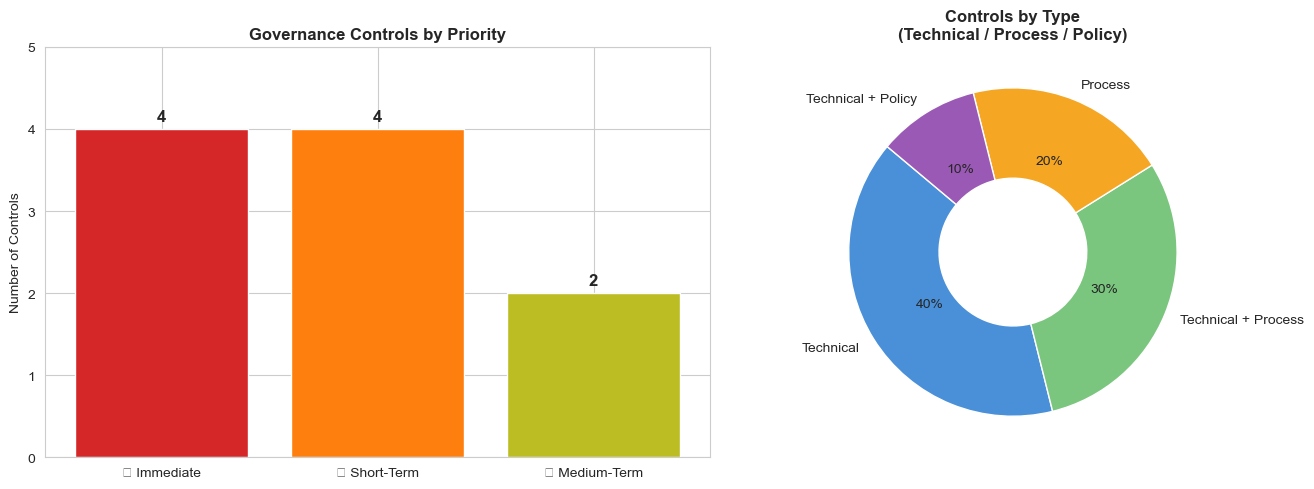

In [34]:
# ============================================================================
# VISUALISATION: Governance Roadmap — Controls by Priority and Type
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Controls by priority ---
priority_counts = {
    '🔴 Immediate':   immediate,
    '🟠 Short-Term':  short_term,
    '🟡 Medium-Term': medium_term,
}
priority_colors = ['#d62728', '#ff7f0e', '#bcbd22']
axes[0].bar(priority_counts.keys(), priority_counts.values(),
            color=priority_colors, edgecolor='white')
axes[0].set_ylabel('Number of Controls')
axes[0].set_title('Governance Controls by Priority', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(priority_counts.values()) + 1)
for i, (k, v) in enumerate(priority_counts.items()):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=12, fontweight='bold')

# --- Right: Controls by type ---
type_counts = pd.Series([c['type'] for c in governance_roadmap]).value_counts()
axes[1].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.0f%%',
    startangle=140,
    colors=['#4a90d9', '#7bc67e', '#f5a623', '#9b59b6'],
    wedgeprops=dict(width=0.55)
)
axes[1].set_title('Controls by Type\n(Technical / Process / Policy)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Analysis 7: Results and Findings

**Findings:** A total of **10 governance controls** are proposed across 3 priority tiers, addressing all 9 GDPR violations and 6 EU AI Act failures identified in Analyses 1–6. The roadmap is front-loaded: **8 of 10 controls** must be implemented within 90 days to address the most critical regulatory exposure.

---

**🔴 IMMEDIATE (0–30 days) — 4 controls:**

| Control | Type | GDPR Article |
|---|---|---|
| Pseudonymisation pipeline | Technical | Art. 25 + Art. 5(1)(f) |
| Consent tracking system | Technical + Process | Art. 6 + Art. 7 |
| Data retention policy + automated deletion | Technical + Policy | Art. 5(1)(e) |
| Remove unnecessary PII (SSN, IP address) | Technical | Art. 5(1)(c) |

These 4 controls directly remediate the CRITICAL violations found in Analysis 4 and close NovaCred's most severe regulatory exposure. The pseudonymisation pipeline specifically operationalises the approach demonstrated in Analysis 5.

---

**🟠 SHORT-TERM (30–90 days) — 4 controls:**

| Control | Type | GDPR / AI Act Article |
|---|---|---|
| Human oversight workflow | Technical + Process | Art. 22 + AI Act Art. 14 |
| Bias monitoring pipeline | Technical | AI Act Art. 10 + Art. 9 |
| Art. 17 erasure API | Technical | Art. 17 |
| Art. 30 Records of Processing Activities | Process | Art. 30 |

The bias monitoring pipeline is directly motivated by the DI ratios from Notebook 2 (gender DI = 0.773, age DI = 0.769, intersectional DI = 0.667) — automated alerting when DI < 0.8 ensures these violations cannot recur undetected in future decision batches.

---

**🟡 MEDIUM-TERM (90–180 days) — 2 controls:**

| Control | Type | Article |
|---|---|---|
| Data Protection Impact Assessment (DPIA) | Process | Art. 35 |
| AI Act technical documentation & model card | Technical + Process | AI Act Art. 11 |

---

**Control type breakdown:** 40% purely Technical, 30% Technical + Process, 20% Process, 10% Technical + Policy — reflecting that NovaCred's governance failures are primarily structural and require both system-level and organisational intervention.

**Regulatory exposure without remediation:** Failure to implement the immediate controls leaves NovaCred exposed to fines of up to **€20M or 4% of global turnover** under GDPR Art. 83(5) for lawful basis violations, and potential **mandatory suspension** of the AI system under EU AI Act Art. 79.

---

## Summary: Mapping NovaCred to the Privacy Spectrum

The Privacy Spectrum describes three levels of increasing privacy protection: Pseudonymisation → Anonymisation → Differential Privacy. Each technique trades off data utility for privacy guarantees. This section maps all findings from this notebook to their position on the spectrum.

In [40]:
# ============================================================================
# PRIVACY SPECTRUM SUMMARY
# Mapping NovaCred findings to the three-level privacy framework from lecture
# ============================================================================

print('=' * 90)
print('THE PRIVACY SPECTRUM — NOVACRED ASSESSMENT')
print('=' * 90)

spectrum = [
    {
        'level':        '1. PSEUDONYMISATION',
        'description':  'Replace identifiers with tokens/hashes — still personal data under GDPR',
        'novacred':     'DEMONSTRATED',
        'details': [
            'Analysis 5a: SSN pseudonymised via HMAC-SHA256 with secret salt',
            'Analysis 5b: Email pseudonymised via normalised SHA-256',
            'Analysis 5c: All three approaches compared (Tokenization, Hashing, Encryption)',
            f'Result: {df_pseudo["ssn_pseudonymised"].notna().sum()} SSNs + '
            f'{df_pseudo["email_pseudonymised"].notna().sum()} emails successfully pseudonymised',
        ],
        'gdpr_status':  'Still personal data (Art. 4(5)) — reduced risk, not eliminated',
        'reversible':   'Yes (with key/salt/lookup table)',
        'data_utility': 'HIGH — record linkage preserved',
        'colour':       '🟡',
    },
    {
        'level':        '2. ANONYMISATION (k-Anonymity)',
        'description':  'Generalise or suppress values so individuals cannot be singled out',
        'novacred':     'MEASURED — INSUFFICIENT',
        'details': [
            'Analysis 2: k-anonymity measured for 5 quasi-identifier combinations',
            f'Result: k-min = 1 for ZIP-based combinations — 85.8% uniquely identifiable',
            'Analysis 2b: Homogeneity attack detected — l-diversity = 1 in worst case',
            'Conclusion: Current data fails both k-anonymity (k<5) and l-diversity (l<2)',
        ],
        'gdpr_status':  'NOT achieved — data remains personal data (Recital 26)',
        'reversible':   'No (if done correctly)',
        'data_utility': 'MEDIUM — some precision lost through generalisation',
        'colour':       '🟠',
    },
    {
        'level':        '3. DIFFERENTIAL PRIVACY',
        'description':  'Add calibrated noise to outputs — mathematical privacy guarantee',
        'novacred':     'NOT IMPLEMENTED',
        'details': [
            'Not currently applied to any NovaCred data or query outputs',
            'Recommended for: aggregate statistics shared externally (e.g. approval rates)',
            'Mechanism: Randomised response (coin flip trick) or Laplace noise on queries',
            'Would provide strongest guarantee: individual contribution cannot be detected',
        ],
        'gdpr_status':  'Not personal data — strongest GDPR position',
        'reversible':   'No (mathematically impossible)',
        'data_utility': 'LOWER — noise reduces precision of individual records',
        'colour':       '🟢',
    },
]

for level in spectrum:
    print(f'\n{level["colour"]}  {level["level"]}')
    print(f'   Description   : {level["description"]}')
    print(f'   NovaCred      : {level["novacred"]}')
    for d in level['details']:
        print(f'     • {d}')
    print(f'   GDPR status   : {level["gdpr_status"]}')
    print(f'   Reversible?   : {level["reversible"]}')
    print(f'   Data utility  : {level["data_utility"]}')

print('\n' + '=' * 90)
print('OVERALL ASSESSMENT:')
print('  NovaCred has demonstrated Level 1 (Pseudonymisation) for SSN and email.')
print('  Level 2 (Anonymisation) was measured but NOT achieved — k-min = 1, l-min = 1.')
print('  Level 3 (Differential Privacy) is not implemented.')
print('')
print('  Recommendation: Apply k-anonymity generalisation (ZIP truncation, age banding)')
print('  to achieve Level 2, and implement differential privacy for any externally')
print('  shared aggregate statistics to reach Level 3.')
print('=' * 90)

THE PRIVACY SPECTRUM — NOVACRED ASSESSMENT

🟡  1. PSEUDONYMISATION
   Description   : Replace identifiers with tokens/hashes — still personal data under GDPR
   NovaCred      : DEMONSTRATED
     • Analysis 5a: SSN pseudonymised via HMAC-SHA256 with secret salt
     • Analysis 5b: Email pseudonymised via normalised SHA-256
     • Analysis 5c: All three approaches compared (Tokenization, Hashing, Encryption)
     • Result: 495 SSNs + 496 emails successfully pseudonymised
   GDPR status   : Still personal data (Art. 4(5)) — reduced risk, not eliminated
   Reversible?   : Yes (with key/salt/lookup table)
   Data utility  : HIGH — record linkage preserved

🟠  2. ANONYMISATION (k-Anonymity)
   Description   : Generalise or suppress values so individuals cannot be singled out
   NovaCred      : MEASURED — INSUFFICIENT
     • Analysis 2: k-anonymity measured for 5 quasi-identifier combinations
     • Result: k-min = 1 for ZIP-based combinations — 85.8% uniquely identifiable
     • Analysis 2b:

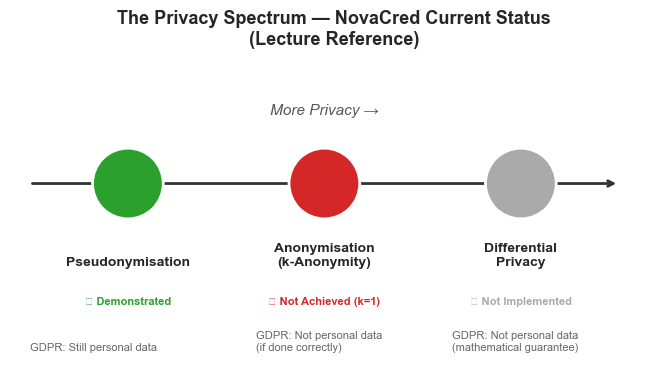

In [41]:
# ============================================================================
# VISUALISATION: Privacy Spectrum — NovaCred Status
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 4))

levels = ['Pseudonymisation', 'Anonymisation\n(k-Anonymity)', 'Differential\nPrivacy']
positions = [0, 1, 2]
colors = ['#2ca02c', '#d62728', '#aaaaaa']  # demonstrated, failed, not implemented
statuses = ['✅ Demonstrated', '❌ Not Achieved (k=1)', '⬜ Not Implemented']

# Draw spectrum arrow
ax.annotate('', xy=(2.5, 0.5), xytext=(-0.5, 0.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#333333'))
ax.text(1.0, 0.85, 'More Privacy →', ha='center', fontsize=11,
        fontstyle='italic', color='#555555')

# Draw circles at each level
for pos, level, color, status in zip(positions, levels, colors, statuses):
    circle = plt.Circle((pos, 0.5), 0.18, color=color, ec='white', linewidth=2, zorder=3)
    ax.add_patch(circle)
    ax.text(pos, 0.08, level, ha='center', fontsize=10, fontweight='bold')
    ax.text(pos, -0.12, status, ha='center', fontsize=8, color=color, fontweight='bold')

# Annotations
ax.text(-0.5, -0.35, 'GDPR: Still personal data', fontsize=8, color='#666')
ax.text(0.65, -0.35, 'GDPR: Not personal data\n(if done correctly)', fontsize=8, color='#666')
ax.text(1.65, -0.35, 'GDPR: Not personal data\n(mathematical guarantee)', fontsize=8, color='#666')

ax.set_xlim(-0.6, 2.7)
ax.set_ylim(-0.5, 1.1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('The Privacy Spectrum — NovaCred Current Status\n(Lecture Reference)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()